# Simulation

This notebook runs the NYP Women's Health Screening digital twin — from a full 70-year population simulation through to individual patient journeys.

| Section | What you'll see |
|---|---|
| **70-Year Longitudinal Simulation** | How the full patient population moves through the screening program over a generation |
| **Single Patient Trace** | One patient's complete screening journey from entry to end of life |
| **Longitudinal Visualizations** | Trends in screening volume, clinical rates, and revenue across 70 years |
| **1-Year Simulation** | A quick single-year snapshot of daily throughput and outcomes |
| **Step-by-Step Breakdown** | Technical detail on the daily simulation engine — for debugging and development |

---

## Clinical Pathways

The simulation models two cancer screening pathways. Each pathway has two layers:

- **USPSTF** — determines *who* gets screened and *how often*. **This is the primary focus of the model.**
- **ACR / ASCCP** — determines what happens *after* a result comes back. These downstream pathways are modeled but are secondary — the main question we are answering is uptake, not outcomes.

---

### Cervical Cancer Pathway

**Who gets screened (USPSTF)**

| Age | Test | Frequency | USPSTF Recommendation |
|---|---|---|---|
| 21–29 | Cytology (Pap smear) | Every 3 years | Grade A |
| 30–65 | Cytology every 3 years **or** hrHPV alone every 5 years | 3 or 5 years | Grade A |
| < 21 or > 65 | No routine screening | — | Grade D / C |

**What "cytology" and "hrHPV" mean:**
- **Cytology (Pap smear)** — cells from the cervix are examined under a microscope. Results: Normal, ASCUS, LSIL, ASC-H, or HSIL.
- **hrHPV alone** — a molecular test for high-risk strains of human papillomavirus. Results: HPV-Negative or HPV-Positive.

**After an abnormal result (ASCCP — secondary)**

An abnormal Pap or positive HPV leads to colposcopy (a closer look at the cervix). If abnormal tissue is found (CIN2/CIN3), a LEEP procedure removes it. These are tracked in the model but are not the primary metric.

---

### Lung Cancer Pathway

**Who gets screened (USPSTF)**

| Criteria | Requirement | USPSTF Recommendation |
|---|---|---|
| Age | 50–80 years | Grade B |
| Smoking history | ≥ 20 pack-years | Grade B |
| Smoking status | Currently smoking **or** quit within last 15 years | Grade B |

All three criteria must be met. A patient who smoked 30 pack-years but quit 20 years ago is **not** eligible under USPSTF.

**The test: Low-Dose CT (LDCT)**
An annual low-dose CT scan of the chest looks for lung nodules. It is a quick, non-invasive scan — no lab test, no procedure. The result is scored using **Lung-RADS** (1–4), but this scoring is secondary; what matters for USPSTF compliance is whether the eligible patient **received the scan**.

**After a suspicious result (ACR Lung-RADS — secondary)**
RADS 3 or 4 results trigger follow-up imaging or biopsy. Tracked in the model but secondary to uptake.

---

> **Key distinction**: RADS categories and CIN grades are *clinical classification systems* used by radiologists and pathologists after a test is done. They are **not** USPSTF guidelines — USPSTF only specifies who gets the test and how often.


In [1]:
%matplotlib inline

import sys, random, time
sys.path.insert(0, '../src')

import config as cfg
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import numpy as np

from patient import Patient
from population import sample_patient, draw_mortality, get_mortality_prob
from screening import get_eligible_screenings, run_screening_step
from followup import run_cervical_followup, run_lung_followup
from metrics import initialize_metrics, record_screening, compute_rates, compute_revenue, print_revenue_summary
from runner import SimulationRunner
from db import SimulationDB

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

### How to Use This Notebook

Run each cell from top to bottom by pressing **Shift + Enter**. You do not need to understand the code — the charts and printed summaries are the outputs to focus on.

The cell immediately below loads the simulation engine and supporting libraries. Run it once at the start of each session before anything else.

---

## 70-Year Longitudinal Simulation

The full simulation models a stable population of patients cycling through NYP's screening program over a 70-year horizon. New patients enter continuously as others age out or die, keeping the active pool roughly constant — the way a real hospital system actually operates over decades.

**Primary question:** Of all patients in the system, how many receive their USPSTF-recommended screenings (Pap cytology, hrHPV, lung LDCT) — and at what rate?


In [2]:
import sys, time, pickle, os
sys.path.insert(0, '../src')

import config as cfg
from runner import SimulationRunner

CACHE_FILE = "metrics_70yr_cache.pkl"

if os.path.exists(CACHE_FILE):
    # ── Load from cache (fast — no re-run needed) ─────────────────────────
    print(f"Loading cached 70-year metrics from {CACHE_FILE}...")
    with open(CACHE_FILE, "rb") as _f:
        _cache = pickle.load(_f)
    metrics_70yr = _cache["metrics"]
    print(f"  Loaded. Cervical screens: {metrics_70yr['n_screened']['cervical']:,}")
    print(f"  Year checkpoints: {len(metrics_70yr['year_checkpoints'])}")
    print()
    # Re-create a summary-only runner for revenue / db_summary calls
    sim_70yr = SimulationRunner.__new__(SimulationRunner)
    sim_70yr.metrics = metrics_70yr
    sim_70yr.n_days  = cfg.SIM_DAYS
else:
    # ── Full run (first time or after cache deletion) ─────────────────────
    print("No cache found — running full 70-year simulation...")
    print(f"  Pool size   : {cfg.SIMULATED_POPULATION:,} established patients")
    print(f"  Horizon     : {cfg.SIM_YEARS} years ({cfg.SIM_DAYS:,} days)")
    print(f"  Scale factor: 1 sim patient = {cfg.POPULATION_SCALE_FACTOR} NYC women")
    print()

    t0 = time.time()
    sim_70yr = SimulationRunner(
        n_days                = cfg.SIM_DAYS,
        seed                  = cfg.RANDOM_SEED,
        use_stable_population = True,
        db_path               = "nyp_70yr.db",
        reset_db              = True,
    )
    metrics_70yr = sim_70yr.run()
    elapsed = time.time() - t0
    print(f"Simulation complete in {elapsed:.1f}s ({elapsed/60:.1f} min)")
    print()
    sim_70yr.summary()

    # ── Save to cache ─────────────────────────────────────────────────────
    with open(CACHE_FILE, "wb") as _f:
        pickle.dump({"metrics": metrics_70yr}, _f)
    print(f"[Cached → {CACHE_FILE}]")


SyntaxError: unterminated string literal (detected at line 47) (706600876.py, line 47)

### What the 70-Year Run Models

The simulation maintains a stable pool of **15,000 active patients** cycling through NYP's screening program at all times — roughly proportional to the real NYP women's health patient population using a scale factor. New patients enter continuously as others age out, die, or are lost to follow-up, keeping the pool size roughly constant the way a real hospital system does over decades.

Key parameters (all set in `config.py` and replaceable with real NYP data):

| Parameter | Current value | Source |
|---|---|---|
| Active patient pool | 15,000 | Placeholder — replace with NYP census |
| Daily patient volume | 200/day | Placeholder — replace with NYP scheduling data |
| Simulation horizon | 70 years | Full patient lifetime |
| Random seed | 42 | Fixed for reproducibility — change to test variance |

**This cell may take several minutes to run.** Once complete, all charts below will populate automatically.

In [3]:
# ── Database summary + revenue analysis ─────────────────────────────────────
print("=== DATABASE SUMMARY ===")
sim_70yr.db_summary()

print()
print("=== REVENUE ANALYSIS ===")
sim_70yr.revenue_summary()

# Keep DB open for longitudinal plots below


=== DATABASE SUMMARY ===


NameError: name 'sim_70yr' is not defined

### Who Gets Screened? USPSTF Eligibility & Screening Outcomes

The charts below answer the core USPSTF question: **of all patients in the system, how many actually receive the screenings they are supposed to receive?** USPSTF guidelines specify age windows for cervical (age 21–65) and lung (age 50–80 with ≥20 pack-years) screening. The panels show (A) annual screening volume by type, (B) the share of eligible patients actually screened each year, and (C) what happened after the screen — normal, abnormal, or lost to follow-up.

In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# USPSTF SCREENING OVERVIEW — 70-Year Simulation
# Three panels:
#   A  Annual screening volume (cervical vs lung) — who is actually screened
#   B  Screening uptake rate (% of eligible patients seen that year)
#   C  Outcome breakdown — of all screens, how many were normal / abnormal /
#      lost to follow-up after abnormal result
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

chk = metrics_70yr["year_checkpoints"]

if not chk:
    print("No year checkpoints — re-run the simulation cell above.")
else:
    years    = [c["year"] for c in chk]

    def ann(key):
        vals = [c[key] for c in chk]
        return [vals[0]] + [vals[i] - vals[i-1] for i in range(1, len(vals))]

    ann_cerv  = ann("cum_cervical")
    ann_lung  = ann("cum_lung")
    ann_colp  = ann("cum_colposcopy")
    ann_leep  = ann("cum_leep")
    ann_exits = ann("cum_exits")

    # ── estimate abnormal screens each year (colposcopy is the proxy) ─────
    ann_abnormal = ann_colp  # colposcopy triggered by abnormal cervical result
    # Normal screens = total cervical screens minus those that triggered colposcopy
    ann_normal_cerv = [max(0, c - a) for c, a in zip(ann_cerv, ann_abnormal)]

    # Screening uptake rate: cerv screens / population (proxy — not exact eligibles)
    # Use SIMULATED_POPULATION as denominator; scale roughly for age-eligible fraction (~60%)
    import config as cfg
    eligible_approx = cfg.SIMULATED_POPULATION * 0.62   # ~62% of women aged 21–65
    lung_eligible_approx = cfg.SIMULATED_POPULATION * 0.10  # ~10% meet USPSTF lung criteria

    uptake_cerv = [100 * s / eligible_approx for s in ann_cerv]
    uptake_lung = [100 * s / max(lung_eligible_approx, 1) for s in ann_lung]

    # ── Overall outcome totals (last checkpoint = cumulative) ────────────
    cum_cerv    = chk[-1]["cum_cervical"]
    cum_lung    = chk[-1]["cum_lung"]
    cum_colp    = chk[-1]["cum_colposcopy"]
    cum_leep    = chk[-1]["cum_leep"]
    cum_exits   = chk[-1]["cum_exits"]
    cum_ltfu    = metrics_70yr.get("n_ltfu", 0)

    cerv_normal  = max(0, cum_cerv - cum_colp)
    cerv_abnorm  = cum_colp
    cerv_ltfu    = max(0, int(cum_ltfu * cum_cerv / max(cum_cerv + cum_lung, 1)))
    cerv_treated = cum_leep

    lung_rads4   = metrics_70yr["lung_rads_distribution"].get("RADS_4A", 0) +                    metrics_70yr["lung_rads_distribution"].get("RADS_4B_4X", 0)
    lung_normal  = max(0, cum_lung - lung_rads4)
    lung_abnorm  = lung_rads4
    lung_ltfu    = max(0, int(cum_ltfu * cum_lung / max(cum_cerv + cum_lung, 1)))

    # ─────────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.patch.set_facecolor("white")

    # ── Panel A: Annual Screening Volume ─────────────────────────────────
    ax = axes[0]
    bar_w = 0.4
    x = np.arange(len(years))
    ax.bar(x - bar_w/2, ann_cerv, bar_w, color="#4472C4", alpha=0.85, label="Cervical (Pap / HPV)")
    ax.bar(x + bar_w/2, ann_lung, bar_w, color="#70AD47", alpha=0.85, label="Lung (LDCT)")
    ax.set_xticks(x[::5])
    ax.set_xticklabels([str(y) for y in years[::5]], fontsize=9)
    ax.set_xlabel("Simulation Year", fontsize=10)
    ax.set_ylabel("Screens Completed", fontsize=10)
    ax.set_title("A  Annual Screening Volume", fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{int(v):,}"))
    ax.set_facecolor("#f9f9f9")

    # add USPSTF label bands
    ax.text(0.5, 0.97, "USPSTF recommends cervical age 21–65 · lung age 50–80 (≥20 pk-yr)",
            transform=ax.transAxes, fontsize=7.5, ha="center", va="top",
            color="#555555", style="italic")

    # ── Panel B: Screening Uptake Rate ────────────────────────────────────
    ax = axes[1]
    ax.plot(years, uptake_cerv, color="#4472C4", lw=2.2, marker="o", markersize=3,
            label="Cervical uptake (% of eligible)")
    ax.plot(years, uptake_lung, color="#70AD47", lw=2.2, marker="s", markersize=3,
            label="Lung uptake (% of eligible)")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_xlabel("Simulation Year", fontsize=10)
    ax.set_ylabel("Uptake Rate (%)", fontsize=10)
    ax.set_title("B  Screening Uptake — % of Eligible", fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)
    ax.set_facecolor("#f9f9f9")
    ax.text(0.5, 0.03,
            "Denominator: estimated eligible population (cervical ~62%, lung ~10%)",
            transform=ax.transAxes, fontsize=7, ha="center", color="#888888", style="italic")

    # ── Panel C: Outcome Breakdown ────────────────────────────────────────
    ax = axes[2]
    categories = ["Cervical\nNormal", "Cervical\nAbnormal",
                  "Cervical\nTreated (LEEP)", "Lung\nNormal", "Lung\nSuspicious\n(RADS 4)"]
    values  = [cerv_normal, cerv_abnorm, cerv_treated, lung_normal, lung_abnorm]
    colors  = ["#4472C4", "#ED7D31", "#C00000", "#70AD47", "#FF8C00"]
    bars    = ax.bar(range(len(categories)), values, color=colors, alpha=0.88, edgecolor="white", lw=0.8)
    ax.set_xticks(range(len(categories)))
    ax.set_xticklabels(categories, fontsize=8.5)
    ax.set_ylabel("Cumulative Patient Count", fontsize=10)
    ax.set_title("C  Screening Outcomes (70-Year Totals)", fontsize=11, fontweight="bold")
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{int(v):,}"))
    ax.set_facecolor("#f9f9f9")
    # label each bar with its value
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.01,
                f"{int(val):,}", ha="center", va="bottom", fontsize=8.5, fontweight="bold")
    ax.text(0.5, 0.97, "Abnormal cervical → colposcopy  ·  Suspicious lung → RADS 4 biopsy pathway",
            transform=ax.transAxes, fontsize=7, ha="center", va="top",
            color="#555555", style="italic")

    fig.suptitle(
        "USPSTF Screening Overview — 70-Year Simulation",
        fontsize=13, fontweight="bold", y=1.01
    )
    plt.tight_layout()
    plt.show()


SyntaxError: unterminated string literal (detected at line 105) (725465468.py, line 105)

### Patient Flow: Entries, Exits & Retention

Three charts that answer the core flow question: **where do patients come from, where do they go, and how long do they stay?**

- **Entry density** — how patients arrive (by provider destination and visit type). Helps NYP understand which referral pathways drive the most volume.
- **Exit breakdown** — why patients leave the system (completed treatment, lost to follow-up, mortality, etc.).
- **Retention distribution** — how many days a patient stays in the system from first contact to exit. Long tails indicate patients tracked through multi-step follow-up pathways.

In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from collections import defaultdict

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# PATIENT FLOW — Entries · Exits · Retention (70-Year Simulation)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

m = metrics_70yr

# ── Entry data ───────────────────────────────────────────────────────────
dest_counts = dict(m.get("entries_by_destination", {}))
type_counts = dict(m.get("entries_by_type", {}))

dest_labels = {
    "pcp":           "Primary Care (PCP)",
    "gynecologist":  "Gynecologist",
    "specialist":    "Specialist",
    "er":            "Emergency Room",
}
type_labels = {
    "outpatient": "Scheduled Outpatient",
    "drop_in":    "Drop-in / Walk-in",
}

# ── Exit data ────────────────────────────────────────────────────────────
exit_counts = dict(m.get("exits_by_reason", {}))
exit_labels = {
    "treated":           "Treated (completed care)",
    "untreated":         "Untreated (declined)",
    "lost_to_followup":  "Lost to Follow-up",
    "mortality":         "Mortality",
    "ineligible":        "Ineligible / Aged out",
}
exit_colors = {
    "treated":           "#2E7D32",
    "untreated":         "#F57C00",
    "lost_to_followup":  "#C62828",
    "mortality":         "#424242",
    "ineligible":        "#9E9E9E",
}

# ── Retention data ────────────────────────────────────────────────────────
retention_days = m.get("days_in_system", [])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor("white")
fig.suptitle("Patient Flow — Entries, Exits & Retention (70-Year Simulation)",
             fontsize=13, fontweight="bold", y=1.01)

# ── Panel A: Entry density by destination ────────────────────────────────
ax = axes[0]
if dest_counts:
    dests  = list(dest_counts.keys())
    counts = [dest_counts[d] for d in dests]
    lbls   = [dest_labels.get(d, d) for d in dests]
    colors = ["#4472C4", "#ED7D31", "#A5A5A5", "#FF0000"][:len(dests)]
    bars = ax.barh(range(len(dests)), counts, color=colors, alpha=0.82, edgecolor="white", height=0.6)
    ax.set_yticks(range(len(dests)))
    ax.set_yticklabels(lbls, fontsize=10)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
    for bar, val in zip(bars, counts):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                f"{val:,}", va="center", fontsize=9)
    # Add visit type as a secondary bar (stacked inset)
    if type_counts:
        total = sum(type_counts.values())
        op_frac = type_counts.get("outpatient", 0) / max(total, 1)
        ax.text(0.98, -0.08,
                f"Scheduled outpatient: {op_frac:.0%}  ·  Drop-in: {1-op_frac:.0%}",
                transform=ax.transAxes, fontsize=8, ha="right", color="#555",
                style="italic")
else:
    ax.text(0.5, 0.5, "No entry data\n(run with updated runner.py)",
            transform=ax.transAxes, ha="center", va="center", fontsize=10, color="#888")
ax.set_title("A  Entry Density by Provider Destination", fontsize=11, fontweight="bold")
ax.set_xlabel("Patient-visits (total over 70 years)", fontsize=9)
ax.set_facecolor("#f9f9f9")

# ── Panel B: Exit breakdown ───────────────────────────────────────────────
ax = axes[1]
if exit_counts:
    reasons = list(exit_counts.keys())
    vals    = [exit_counts[r] for r in reasons]
    lbls    = [exit_labels.get(r, r) for r in reasons]
    colors  = [exit_colors.get(r, "#BDBDBD") for r in reasons]
    bars = ax.barh(range(len(reasons)), vals, color=colors, alpha=0.82, edgecolor="white", height=0.6)
    ax.set_yticks(range(len(reasons)))
    ax.set_yticklabels(lbls, fontsize=10)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
    total_exits = sum(vals)
    for bar, val in zip(bars, vals):
        pct = 100 * val / max(total_exits, 1)
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                f"{val:,}  ({pct:.1f}%)", va="center", fontsize=9)
else:
    ax.text(0.5, 0.5, "No exit data\n(run with updated runner.py)",
            transform=ax.transAxes, ha="center", va="center", fontsize=10, color="#888")
ax.set_title("B  Exit Breakdown by Reason", fontsize=11, fontweight="bold")
ax.set_xlabel("Patients", fontsize=9)
ax.set_facecolor("#f9f9f9")

# ── Panel C: Retention distribution ──────────────────────────────────────
ax = axes[2]
if retention_days:
    retention_yrs = [d / 365 for d in retention_days]
    ax.hist(retention_yrs, bins=40, color="#4472C4", alpha=0.75, edgecolor="white", lw=0.5)
    median_yrs = np.median(retention_yrs)
    mean_yrs   = np.mean(retention_yrs)
    ax.axvline(median_yrs, color="#C00000", lw=2, ls="--", label=f"Median: {median_yrs:.1f} yr")
    ax.axvline(mean_yrs,   color="#FF8C00", lw=2, ls=":",  label=f"Mean: {mean_yrs:.1f} yr")
    ax.legend(fontsize=9)
    ax.set_xlabel("Years in System", fontsize=9)
    ax.set_ylabel("Number of Patients", fontsize=9)
    p90 = np.percentile(retention_yrs, 90)
    ax.text(0.97, 0.95, f"90th pct: {p90:.1f} yr",
            transform=ax.transAxes, ha="right", va="top", fontsize=9, color="#555")
else:
    ax.text(0.5, 0.5, "No retention data\n(run with updated runner.py)",
            transform=ax.transAxes, ha="center", va="center", fontsize=10, color="#888")
ax.set_title("C  Patient Retention Distribution", fontsize=11, fontweight="bold")
ax.set_facecolor("#f9f9f9")

plt.tight_layout()
plt.show()


NameError: name 'metrics_70yr' is not defined

### Reading the Simulation Summary

The output below shows two things:

**Database summary** — total patient encounters written to the SQLite database (`nyp_70yr.db`). This is a persistent record of every simulated patient event and can be queried directly with SQL if needed.

**Revenue analysis** — procedure revenue across the full 70-year run. These figures use **placeholder CPT rates** and are not reflective of NYP contract rates. Replace the values in `config.py → PROCEDURE_REVENUE` with actual NYP rates before drawing any financial conclusions.

---

## Single Patient Trace

A randomly selected patient followed from her first visit to the end of her screening-eligible life. Every screening event, abnormal result, follow-up procedure, and clinical decision is printed in chronological order and rendered as a timeline.

In [6]:

import sys, random
sys.path.insert(0, '../src')

from patient import Patient
from population import sample_patient, draw_mortality, get_mortality_prob
from screening import run_screening_step
from followup import run_cervical_followup, run_lung_followup
from metrics import initialize_metrics, record_screening
import config as cfg


def trace_single_patient(
    starting_age: int   = 25,
    has_cervix:   bool  = True,
    smoker:       bool  = True,
    pack_years:   float = 15.0,   # accumulates +1/year while still smoking
    hpv_positive: bool  = False,
    race:         str   = "Hispanic/Latino",
    insurance:    str   = "Medicaid",
    seed:         int   = 42,
) -> tuple:
    """
    Simulate one patient's full 70-year screening journey, year by year.

    Uses the EXACT same eligibility, result-draw, follow-up, and mortality
    functions as the full SimulationRunner — just for a single patient so
    every event is visible and the logic can be inspected step by step.

    Annual visit cadence
    --------------------
    The patient sees their provider once per year (every 365 days).
    • Cervical screening is every 3 years (ages 21–65) enforced by
      is_due_for_screening(), which checks last_cervical_screen_day.
    • HPV-alone (ages 30–65) carries a 5-year interval — so if that
      test is randomly assigned, the patient is skipped the following
      year's cervical check.
    • Lung screening is every year once age ≥ 50 AND pack_years ≥ 20
      AND still smoking or quit within 15 years.
    • Pack-years grow +1 per year while smoker=True.

    Follow-up logic
    ---------------
    • Abnormal cervical result → colposcopy at visit_day + 30.
    • CIN2/CIN3 at colposcopy → treatment (LEEP or cone) at colpo + 14 days.
    • RADS 4A/4B at LDCT → lung biopsy pathway triggered immediately.
    • LTFU at any clinical node: patient is RE-ACTIVATED and continues
      annual visits (mirrors established-patient logic in SimulationRunner).

    Mortality
    ---------
    Annual Bernoulli draw from age-specific US life-table rates.
    If the draw fires, the annual loop breaks and the final event is logged.

    Returns
    -------
    patient   : Patient with final clinical state after 70 years (or death)
    metrics   : standard metrics dict (same structure as full sim run)
    timeline  : list of (day, age, category, description) tuples for plotting
    """
    random.seed(seed)

    # ── Create patient ─────────────────────────────────────────────────────────
    p = Patient(
        patient_id           = 1,
        day_created          = 0,
        patient_type         = "outpatient",
        destination          = "gynecologist",
        age                  = starting_age,
        race                 = race,
        insurance            = insurance,
        has_cervix           = has_cervix,
        smoker               = smoker,
        pack_years           = pack_years,
        years_since_quit     = 0.0,
        bmi                  = round(random.gauss(27.5, 5.0), 1),
        hpv_positive         = hpv_positive,
        hpv_vaccinated       = False,
        prior_abnormal_pap   = False,
        prior_cin            = None,
        is_established       = True,
        age_at_entry         = starting_age,
        simulation_entry_day = 0,
    )

    metrics  = initialize_metrics()
    timeline = []   # list of (day, age, category, description)
    entry_pack_years = pack_years   # remember entry value for reporting

    timeline.append((0, starting_age, "enrollment",
                     f"Entered system — age {starting_age}, smoker={smoker}, "
                     f"pack_years={pack_years:.0f}, has_cervix={has_cervix}"))
    p.log(0, f"ENTER SYSTEM  age={starting_age}  smoker={smoker}  "
             f"pack_years={pack_years:.0f}  has_cervix={has_cervix}")

    # ── 70-year annual visit loop ──────────────────────────────────────────────
    for year in range(70):
        visit_day   = year * 365
        current_age = starting_age + year
        p.age       = current_age

        # Accumulate pack-years while still smoking (+1 pack-year per year)
        if p.smoker:
            p.pack_years += 1.0

        # ── Annual mortality draw ──────────────────────────────────────────────
        # Scale annual rate to 365-day interval.
        # Draw fires → patient dies; break ends the loop immediately.
        if draw_mortality(p, sweep_days=365):
            p.exit_system(visit_day, "mortality")
            timeline.append((visit_day, current_age, "mortality",
                             f"Death at age {current_age} "
                             f"(annual prob ≈ {get_mortality_prob(current_age):.2%})"))
            p.log(visit_day, f"MORTALITY at age {current_age}")
            break

        # ── Annual provider visit ──────────────────────────────────────────────
        p.visit_count += 1
        p.log(visit_day, f"ANNUAL VISIT #{p.visit_count}  age={current_age}  "
                         f"pack_years={p.pack_years:.0f}")

        # ── Screen for each active cancer ──────────────────────────────────────
        for cancer in cfg.ACTIVE_CANCERS:

            result = run_screening_step(p, cancer, visit_day, metrics)

            # None means: not due yet, not eligible, or LTFU in lung pre-LDCT step
            if result is None:
                if not p.active:   # re-activate if lung pre-LDCT fired exit
                    p.active = True; p.exit_reason = None; p.exit_day = None
                continue

            record_screening(metrics, p, cancer, result)

            # Classify for the timeline
            if cancer == "cervical":
                is_abn   = result not in ("NORMAL", "HPV_NEGATIVE")
            else:
                is_abn   = result in ("RADS_4A", "RADS_4B_4X")
            category = "screen_abnormal" if is_abn else "screen_normal"
            timeline.append((visit_day, current_age, category,
                             f"{cancer.upper()} screen: {result}"))

            # ── Cervical follow-up ─────────────────────────────────────────────
            if cancer == "cervical" and result not in ("NORMAL", "HPV_NEGATIVE"):
                colpo_day = visit_day + 30
                run_cervical_followup(p, colpo_day, metrics)

                if p.colposcopy_result:
                    timeline.append((colpo_day, current_age, "colposcopy",
                                     f"Colposcopy → {p.colposcopy_result}"))

                if p.treatment_type and p.treatment_type != "surveillance":
                    treat_day = colpo_day + cfg.FOLLOWUP_DELAY_DAYS.get(p.treatment_type, 14)
                    timeline.append((treat_day, current_age, "treatment",
                                     f"Treatment: {p.treatment_type.upper()}"))

                if not p.active:   # re-activate post-LTFU/treatment so cycle continues
                    p.active = True; p.exit_reason = None; p.exit_day = None
                p.colposcopy_result = None   # reset for next screening cycle
                p.treatment_type    = None

            # ── Lung follow-up ─────────────────────────────────────────────────
            elif cancer == "lung":
                # Record biopsy pathway entry BEFORE running follow-up.
                # run_lung_followup may modify p.lung_result internally
                # (e.g. biopsy result overwrites it), so the check must
                # happen here while we still have the LDCT result.
                if result in ("RADS_4A", "RADS_4B_4X"):
                    fu_day = visit_day + 1
                    timeline.append((fu_day, current_age, "lung_followup",
                                     f"Lung biopsy pathway triggered ({result})"))

                run_lung_followup(p, visit_day + 1, metrics)
                if not p.active:
                    p.active = True; p.exit_reason = None; p.exit_day = None

    else:
        # Loop completed all 70 years without mortality
        end_age = starting_age + 70
        timeline.append((70 * 365, end_age, "end_of_sim",
                         f"End of simulation — survived to age {end_age}"))
        p.log(70 * 365, f"END OF SIMULATION  age={end_age}")

    # Attach entry pack_years so the viz cell can reference it
    p._entry_pack_years = entry_pack_years
    return p, metrics, timeline


print("trace_single_patient() defined.")


trace_single_patient() defined.


### How the Patient Trace Works

The trace function runs a single patient through the full simulation from her entry age to age 100 (or death), stepping through every annual visit, screening event, abnormal result, follow-up referral, and clinical decision.

At each step, the simulation:
1. Checks whether the patient is due for screening based on her age and the time since her last test
2. Draws a result from the age-appropriate probability table
3. Routes abnormal results to the correct follow-up pathway (colposcopy, LEEP, or lung biopsy)
4. Applies an annual mortality draw based on her current age

The patient's full event history is stored in `timeline` and printed as a chronological log, then rendered as the colour-coded chart below.

In [7]:
# Randomly sample a patient profile to trace
random.seed(None)   # truly random each run; set an int for reproducibility

_sample = sample_patient(patient_id=0, day_created=0, destination="gynecologist", patient_type="outpatient")

patient, pt_metrics, timeline = trace_single_patient(
    starting_age = _sample.age,
    has_cervix   = _sample.has_cervix,
    smoker       = _sample.smoker,
    pack_years   = _sample.pack_years,
    hpv_positive = _sample.hpv_positive,
    race         = _sample.race,
    insurance    = _sample.insurance,
    seed         = random.randint(0, 99999),
)

print(f"{'='*66}")
print(f"  Randomly selected patient")
print(f"  Entry age={patient.age_at_entry}  |  smoker={patient.smoker}  |  "
      f"has_cervix={patient.has_cervix}  |  race={patient.race}")
print(f"  Pack-years at entry: {getattr(patient, '_entry_pack_years', patient.pack_years):.0f}")
print(f"  Total provider visits: {patient.visit_count}")
print(f"{'='*66}\n")

for day, event in patient.event_log:
    year = day // 365
    age  = patient.age_at_entry + year
    print(f"  Day {day:>6}  (age {age:>3})  {event}")

print()
print(f"Final age     : {patient.age}")
print(f"Exit reason   : {patient.exit_reason or 'alive at end of simulation'}")
print(f"Cervical scr  : {pt_metrics['n_screened']['cervical']}")
print(f"Lung scr      : {pt_metrics['n_screened']['lung']}")
print(f"Colposcopies  : {pt_metrics['n_colposcopy']}")
print(f"Treated       : {pt_metrics['n_treated']}")

TypeError: sample_patient() missing 2 required positional arguments: 'destination' and 'patient_type'

The cell below draws a **randomly selected patient** from the population distribution each time it is run. To trace the same patient repeatedly (e.g. for a presentation), replace `random.seed(None)` with a fixed integer like `random.seed(7)`. The printed summary beneath the chart shows her demographics, number of screenings, and final outcome.

In [8]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# PATIENT TRACE  — USPSTF Screening Windows & Outcome
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# The top panel shows the USPSTF guideline windows (the age ranges when
# cervical and lung screening should happen) alongside every screening event
# and the patient outcome. The bottom panel compresses all clinical follow-up
# (colposcopy, treatment, lung biopsy) into a single track so the USPSTF
# story is not obscured.

entry_pk = getattr(patient, "_entry_pack_years", patient.pack_years)
outcome_str = (
    f"Died age {patient.age}" if patient.exit_reason == "mortality"
    else f"Alive at simulation end (age {patient.age})"
    if not patient.exit_reason
    else f"Lost to follow-up (age {patient.age})"
)
outcome_color = (
    "#C00000" if patient.exit_reason == "mortality"
    else "#70AD47" if not patient.exit_reason
    else "#FF8C00"
)

# ── collect events ────────────────────────────────────────────────────────
enroll_events, normal_events, abnormal_events, followup_events, mortality_events = [], [], [], [], []
for day, age, category, desc in timeline:
    if   category == "enrollment":     enroll_events.append((age, desc))
    elif category == "screen_normal":  normal_events.append((age, desc))
    elif category == "screen_abnormal":abnormal_events.append((age, desc))
    elif category in ("colposcopy", "treatment", "lung_followup"): followup_events.append((age, desc))
    elif category == "mortality":      mortality_events.append((age, desc))

# ── layout ────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(17, 7))
gs  = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.08, figure=fig)
ax_top = fig.add_subplot(gs[0])
ax_bot = fig.add_subplot(gs[1], sharex=ax_top)

age_min = patient.age_at_entry
age_max = patient.age_at_entry + 71

for ax in (ax_top, ax_bot):
    ax.set_facecolor("#f9f9f9")
    ax.set_xlim(age_min - 1, age_max)
    for decade in range(25, age_max, 5):
        ax.axvline(decade, color="#cccccc", linewidth=0.5, zorder=1)

# ── USPSTF eligibility windows (top panel) ───────────────────────────────
cerv_start = max(21, age_min)
cerv_end   = min(65, age_max)
lung_start, lung_end = 50, 80

if patient.has_cervix and cerv_start < cerv_end:
    ax_top.axvspan(cerv_start, cerv_end, alpha=0.18, color="#4472C4", zorder=0,
                   label="USPSTF cervical eligibility (age 21–65)")
    ax_top.annotate("USPSTF\nCervical\nWindow",
                    xy=((cerv_start + min(cerv_end, cerv_start + 12)) / 2, 2.6),
                    fontsize=8, color="#2155A3", ha="center", va="center", fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.2", fc="#d9e4f5", ec="none", alpha=0.7))

if patient.smoker:
    ax_top.axvspan(lung_start, lung_end, alpha=0.15, color="#70AD47", zorder=0,
                   label="USPSTF lung eligibility (age 50–80)")
    ax_top.annotate("USPSTF\nLung\nWindow",
                    xy=(65, 2.6),
                    fontsize=8, color="#375623", ha="center", va="center", fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.2", fc="#e2efd9", ec="none", alpha=0.7))

# ── top panel: screening events on 3 y-lanes ─────────────────────────────
#   Lane 2 = normal screens    Lane 1 = abnormal screens   Lane 0 = enrollment
for age, desc in enroll_events:
    ax_top.scatter(age, 0, color="#888888", marker="s", s=64, zorder=5, edgecolors="white", lw=0.6)
    ax_top.text(age, 0.22, "Enrolled", fontsize=6.5, ha="center", color="#555555", style="italic")

for age, desc in normal_events:
    ax_top.scatter(age, 1.2, color="#4472C4", marker="o", s=72, zorder=5, edgecolors="white", lw=0.6)

for age, desc in abnormal_events:
    ax_top.scatter(age, 1.8, color="#ED7D31", marker="o", s=88, zorder=5, edgecolors="white", lw=0.6)
    short = desc.split(":")[1].strip() if ":" in desc else desc[:18]
    ax_top.text(age, 2.1, short, fontsize=5.5, ha="center", color="#C55A11", style="italic")

for age, desc in mortality_events:
    ax_top.scatter(age, 0.6, color="#C00000", marker="X", s=120, zorder=6, edgecolors="white", lw=0.7)
    ax_top.text(age, 0.85, "Mortality", fontsize=6.5, ha="center", color="#C00000", fontweight="bold")

# outcome annotation (right edge)
ax_top.annotate(
    outcome_str,
    xy=(age_max - 1, 0.5), xytext=(age_max - 1, 0.5),
    fontsize=9, ha="right", va="center", color=outcome_color, fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=outcome_color, alpha=0.9)
)

# ── top panel formatting ─────────────────────────────────────────────────
ax_top.set_yticks([0, 1.2, 1.8])
ax_top.set_yticklabels(["Enrolled", "Screen — Normal", "Screen — Abnormal"], fontsize=9)
ax_top.set_ylim(-0.5, 3.1)
ax_top.tick_params(labelbottom=False)
ax_top.set_ylabel("Screening Event", fontsize=10)

# ── bottom panel: clinical follow-up (colposcopy, treatment, biopsy) ─────
for age, desc in followup_events:
    ax_bot.scatter(age, 0, color="#C00000", marker="^", s=72, zorder=5, edgecolors="white", lw=0.6)
    short = desc.split(":")[1].strip() if ":" in desc else desc[:15]
    ax_bot.text(age, 0.2, short, fontsize=5.5, ha="center", color="#C00000", style="italic")

ax_bot.set_yticks([0])
ax_bot.set_yticklabels(["Clinical Follow-up"], fontsize=9)
ax_bot.set_ylim(-0.6, 0.9)
ax_bot.set_xlabel("Patient Age (years)", fontsize=11)
ax_bot.set_xticks(range(int(age_min), int(age_max), 5))

# ── legend ───────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color="#4472C4", alpha=0.4, label="USPSTF Cervical Window (21–65)"),
    mpatches.Patch(color="#70AD47", alpha=0.4, label="USPSTF Lung Window (50–80)"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#4472C4", markersize=8, label="Screen — Normal"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#ED7D31", markersize=8, label="Screen — Abnormal"),
    plt.Line2D([0], [0], marker="^", color="w", markerfacecolor="#C00000", markersize=8, label="Clinical Follow-up"),
    plt.Line2D([0], [0], marker="X", color="w", markerfacecolor="#C00000", markersize=9, label="Mortality"),
]
ax_top.legend(handles=legend_handles, loc="upper left", fontsize=8, framealpha=0.92, ncol=3)

# ── title ─────────────────────────────────────────────────────────────────
fig.suptitle(
    f"70-Year Patient Journey  |  Entry age {patient.age_at_entry}  |  "
    f"{'Smoker' if patient.smoker else 'Non-smoker'} ({entry_pk:.0f} pk-yr)  |  "
    f"Cervical screens: {pt_metrics['n_screened']['cervical']}  ·  "
    f"Lung screens: {pt_metrics['n_screened']['lung']}  ·  "
    f"Follow-ups: {pt_metrics['n_colposcopy'] + pt_metrics['n_treated']}",
    fontsize=11, fontweight="bold", y=1.01
)

plt.tight_layout()
plt.show()


SyntaxError: unterminated string literal (detected at line 60) (2297907024.py, line 60)

#### Patient Scheduling Detail

How long this patient waited between care steps. Each bar is the gap in days between two consecutive events. Long bars represent scheduling delays or periods between routine screens — the key inputs for calibrating wait time distributions against NYP data.

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Scheduling detail for single patient ─────────────────────────────────────
cat_colors = {
    'screen_normal':   '#4472C4',
    'screen_abnormal': '#ED7D31',
    'colposcopy':      '#FF0000',
    'treatment':       '#C00000',
    'lung_followup':   '#70AD47',
    'mortality':       '#000000',
}
cat_labels = {
    'screen_normal':   'Screen (normal)',
    'screen_abnormal': 'Screen (abnormal)',
    'colposcopy':      'Colposcopy',
    'treatment':       'Treatment',
    'lung_followup':   'Lung follow-up',
    'mortality':       'Mortality',
}

care_events = [
    (day, age, cat, desc)
    for day, age, cat, desc in timeline
    if cat in cat_colors
]

if len(care_events) < 2:
    print("This patient had fewer than 2 recorded care events — no scheduling gaps to show.")
    print(f"Events recorded: {len(care_events)}")
else:
    gaps = [
        {
            "from_age":  care_events[i-1][1],
            "to_age":    care_events[i][1],
            "from_day":  care_events[i-1][0],
            "to_day":    care_events[i][0],
            "gap_days":  care_events[i][0] - care_events[i-1][0],
            "from_cat":  care_events[i-1][2],
            "to_cat":    care_events[i][2],
            "to_desc":   care_events[i][3],
        }
        for i in range(1, len(care_events))
    ]

    fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(gaps) * 0.45 + 2)))

    # ── Panel A: Gantt-style — time between events ────────────────────────────
    ax = axes[0]
    for i, g in enumerate(gaps):
        col = cat_colors.get(g['to_cat'], '#888')
        ax.barh(i, g['gap_days'], left=g['from_age'], height=0.55,
                color=col, alpha=0.78, edgecolor='white')
        ax.text(g['from_age'] + g['gap_days'] / 2, i,
                f"{g['gap_days']}d", ha='center', va='center',
                fontsize=7.5, fontweight='bold', color='white')

    y_labels = [
        f"→ {cat_labels.get(g['to_cat'], g['to_cat'])}  (age {g['to_age']:.0f})"
        for g in gaps
    ]
    ax.set_yticks(range(len(gaps)))
    ax.set_yticklabels(y_labels, fontsize=8)
    ax.set_xlabel('Patient age (years)', fontsize=10)
    ax.set_title('Time Between Consecutive Care Events\n(bar width = days of gap)',
                 fontweight='bold', fontsize=10)
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

    # ── Panel B: Gap lengths ranked ───────────────────────────────────────────
    ax2 = axes[1]
    sorted_gaps = sorted(gaps, key=lambda g: -g['gap_days'])
    gap_days  = [g['gap_days']  for g in sorted_gaps]
    gap_cols  = [cat_colors.get(g['to_cat'], '#888') for g in sorted_gaps]
    gap_xlbls = [
        f"{cat_labels.get(g['to_cat'], g['to_cat'])[:14]}\n(age {g['to_age']:.0f})"
        for g in sorted_gaps
    ]

    bars = ax2.bar(range(len(gap_days)), gap_days, color=gap_cols, alpha=0.82, edgecolor='white')
    ax2.axhline(np.mean(gap_days), color='black', linewidth=1.8, linestyle='--',
                label=f'Mean gap: {np.mean(gap_days):.0f}d')
    ax2.axhline(np.median(gap_days), color='gray', linewidth=1.4, linestyle=':',
                label=f'Median gap: {np.median(gap_days):.0f}d')
    for bar, val in zip(bars, gap_days):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(gap_days) * 0.01,
                 f'{val}d', ha='center', fontsize=7.5)
    ax2.set_xticks(range(len(gap_xlbls)))
    ax2.set_xticklabels(gap_xlbls, fontsize=7, rotation=30, ha='right')
    ax2.set_ylabel('Days between events')
    ax2.set_title(f'Inter-Event Gaps — Ranked Longest to Shortest\n'
                  f'{len(care_events)} care events  ·  {len(gaps)} gaps  ·  '
                  f'Total span: {care_events[-1][0] - care_events[0][0]} days',
                  fontweight='bold', fontsize=10)
    ax2.legend(fontsize=9)
    ax2.grid(axis='y', alpha=0.3)
    ax2.spines[['top', 'right']].set_visible(False)

    # Legend
    legend_patches = [
        mpatches.Patch(color=col, label=cat_labels[cat])
        for cat, col in cat_colors.items()
        if any(g['to_cat'] == cat for g in gaps)
    ]
    ax2.legend(handles=legend_patches, fontsize=8, loc='upper right')

    plt.suptitle('Patient Scheduling Detail — Gaps Between Care Steps',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"\n{'From → To':<45} {'Gap (days)':>11} {'Patient Age':>12}")
    print("-" * 72)
    for g in gaps:
        frm = cat_labels.get(g['from_cat'], g['from_cat'])
        to  = cat_labels.get(g['to_cat'],   g['to_cat'])
        print(f"  {frm:<20} → {to:<20} {g['gap_days']:>11,}  age {g['to_age']:.0f}")

NameError: name 'timeline' is not defined

---

## Longitudinal Visualizations

How the screening program performs year by year across the 70-year horizon.

| Chart | What it shows |
|---|---|
| **Screening Volume Over Time** | Annual cervical and lung screening throughput, with LTFU and pool stability |
| **Clinical Rates Over Time** | How screening, abnormal result, and completion rates evolve across the simulation |
| **Revenue Over Time** | Annual realized revenue by procedure type, cumulative total, and LTFU lost revenue |
| **Patient Journey Cascade** | Cumulative 70-year funnel from provider visit to treatment |
| **Lung Cancer Pathway** | Attrition from eligible smoker to treatment, with RADS distribution |
| **Population Dynamics** | Pool stability, annual throughput, and provider capacity |

In [10]:

# ── Shared helpers ────────────────────────────────────────────────────────────
chk = metrics_70yr["year_checkpoints"]

if not chk:
    print("No year checkpoints — re-run the simulation cell above.")
else:
    years = [c["year"] for c in chk]

    def cum(key):
        return [c[key] for c in chk]

    def ann(key):
        vals = cum(key)
        return [vals[0]] + [vals[i] - vals[i-1] for i in range(1, len(vals))]

    def rolling_avg(series, w=5):
        out = []
        for i in range(len(series)):
            window = series[max(0, i-w+1):i+1]
            out.append(sum(window) / len(window))
        return out

    ann_cerv  = ann("cum_cervical")
    ann_lung  = ann("cum_lung")
    ann_colp  = ann("cum_colposcopy")
    ann_leep  = ann("cum_leep")
    ann_lbx   = ann("cum_lung_biopsy")
    ann_ltx   = ann("cum_lung_treatment")
    ann_ltfu  = ann("cum_ltfu")
    ann_mort  = ann("cum_mortality")
    pool_size = cum("pool_size")

    # ── Chart 1: Screening Volume Over Time ──────────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(17, 8))
    fig.suptitle("Screening Program Performance — Year by Year (70-Year Simulation)",
                 fontsize=13, fontweight="bold", y=1.01)

    # 1a — Cervical screening volume
    ax = axes[0, 0]
    ax.fill_between(years, ann_cerv, alpha=0.25, color="#4dac26")
    ax.plot(years, ann_cerv, color="#4dac26", lw=2, label="Annual")
    ax.plot(years, rolling_avg(ann_cerv), color="#1b7837", lw=1.5, ls="--", label="5-yr avg")
    ax.set_title("Cervical Screenings per Year", fontsize=10, fontweight="bold")
    ax.set_xlabel("Year"); ax.set_ylabel("Screens")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
    ax.legend(fontsize=8); ax.grid(alpha=0.25); ax.spines[["top","right"]].set_visible(False)

    # 1b — Lung LDCT volume
    ax = axes[0, 1]
    ax.fill_between(years, ann_lung, alpha=0.25, color="#2c7bb6")
    ax.plot(years, ann_lung, color="#2c7bb6", lw=2, label="Annual")
    ax.plot(years, rolling_avg(ann_lung), color="#08519c", lw=1.5, ls="--", label="5-yr avg")
    ax.set_title("Lung LDCT Screenings per Year", fontsize=10, fontweight="bold")
    ax.set_xlabel("Year"); ax.set_ylabel("Scans")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.1f}K"))
    ax.legend(fontsize=8); ax.grid(alpha=0.25); ax.spines[["top","right"]].set_visible(False)

    # 1c — Pool stability
    ax = axes[0, 2]
    ax.plot(years, pool_size, color="#54278f", lw=2)
    ax.axhline(cfg.SIMULATED_POPULATION, color="gray", ls="--", lw=1, label=f"Target ({cfg.SIMULATED_POPULATION:,})")
    ax.set_title("Established Patient Pool Size", fontsize=10, fontweight="bold")
    ax.set_xlabel("Year"); ax.set_ylabel("Active patients")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
    ax.legend(fontsize=8); ax.grid(alpha=0.25); ax.spines[["top","right"]].set_visible(False)
    ax.set_ylim(0, cfg.SIMULATED_POPULATION * 1.25)

    # 1d — Colposcopies + LEEP
    ax = axes[1, 0]
    ax.bar(years, ann_colp, color="#f46d43", alpha=0.85, label="Colposcopies", width=0.8)
    ax.bar(years, ann_leep, color="#d73027", alpha=0.85, label="LEEP / cone", width=0.8,
           bottom=ann_colp)
    ax.set_title("Cervical Follow-Up Procedures per Year", fontsize=10, fontweight="bold")
    ax.set_xlabel("Year"); ax.set_ylabel("Procedures")
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.25); ax.spines[["top","right"]].set_visible(False)

    # 1e — Lung biopsies + treatments
    ax = axes[1, 1]
    ax.bar(years, ann_lbx, color="#4292c6", alpha=0.85, label="Lung biopsies", width=0.8)
    ax.bar(years, ann_ltx, color="#08519c", alpha=0.85, label="Lung treatments", width=0.8,
           bottom=ann_lbx)
    ax.set_title("Lung Follow-Up Procedures per Year", fontsize=10, fontweight="bold")
    ax.set_xlabel("Year"); ax.set_ylabel("Procedures")
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.25); ax.spines[["top","right"]].set_visible(False)

    # 1f — LTFU + mortality
    ax = axes[1, 2]
    ax.bar(years, ann_ltfu, color="#969696", alpha=0.85, label="LTFU", width=0.8)
    ax2t = ax.twinx()
    ax2t.plot(years, ann_mort, color="#a50026", lw=1.5, label="Mortality", alpha=0.8)
    ax2t.set_ylabel("Mortality exits", fontsize=8, color="#a50026")
    ax2t.tick_params(axis="y", labelcolor="#a50026", labelsize=8)
    ax.set_title("Annual LTFU & Mortality", fontsize=10, fontweight="bold")
    ax.set_xlabel("Year"); ax.set_ylabel("LTFU count")
    ax.legend(loc="upper left", fontsize=8)
    ax2t.legend(loc="upper right", fontsize=8)
    ax.grid(axis="y", alpha=0.25); ax.spines[["top","right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig("chart1_screening_volume.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Chart 1 saved.")


NameError: name 'metrics_70yr' is not defined

### Comprehensive Analytics — Charts 1 through 8

Eight views of the 70-year simulation output. Each chart answers a specific operational question:

| Chart | Location | Question it answers |
|---|---|---|
| **USPSTF Overview** | 70-Year section (above) | Who gets screened under USPSTF guidelines, and what were the outcomes? |
| **1 — Patient Cascade & LTFU** | Below | Where exactly are patients dropping out of the pathway? |
| **2 — Clinical Rates Over Time** | Below | Are screening and follow-up rates stable, or drifting over the simulation? |
| **3 — Revenue Over Time** | Below | What is the program earning per year, and how much is being left on the table? |
| **4 — Screening Funnel** | Below | How deep does the population reach into the full care cascade? |
| **5 — Lung LDCT Pathway** | Below | How many lung-eligible patients make it from referral to treatment? |
| **6 — Population Dynamics** | Below | Is the patient pool stable? Are capacity constraints binding? |
| **7 — Scheduling & Wait Times** | Below | Where are the bottlenecks, and how close is volume to the capacity ceiling? |

> All probability parameters are **placeholders**. Replace them in `config.py` with NYP EHR-derived rates to calibrate the model to your actual patient population.

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import config as cfg

m   = metrics_70yr   # produced by the run cell above
chk = m["year_checkpoints"]

# ── Build cascade values ──────────────────────────────────────────────────────
total_seen    = m["n_patients"]
eligible      = m["n_eligible_any"]
cerv_screened = m["n_screened"]["cervical"]
lung_screened = m["n_screened"]["lung"]

# Abnormal cervical results (everything except NORMAL and HPV_NEGATIVE)
abnormal_cerv = sum(
    v for k, v in m["cervical_results"].items()
    if k not in ("NORMAL", "HPV_NEGATIVE")
)
hpv_pos       = m["cervical_results"].get("HPV_POSITIVE", 0)
total_abnormal = abnormal_cerv + hpv_pos

colposcopies  = m["n_colposcopy"]
cin2_plus     = (m["colposcopy_results"].get("CIN2", 0)
               + m["colposcopy_results"].get("CIN3", 0))
treated       = m["n_treated"]
ltfu_total    = m["n_ltfu"]

# ── Compute LTFU gaps between steps ──────────────────────────────────────────
ltfu_post_abnormal   = m["ltfu_post_abnormal"]
ltfu_post_colposcopy = m["ltfu_post_colposcopy"]

# ── Chart ─────────────────────────────────────────────────────────────────────
labels = [
    "Patients seen by provider",
    "Eligible for ≥1 screening",
    "Cervical screens completed",
    "Lung LDCT screens completed",
    "Abnormal cervical result",
    "Referred to colposcopy",
    "CIN2+ detected",
    "Treatment completed (LEEP/cone)",
]
values = [
    total_seen, eligible, cerv_screened, lung_screened,
    total_abnormal, colposcopies, cin2_plus, treated,
]

# Colour: teal for screening steps, amber for clinical cascade, green for treatment
colors = ["#2c7bb6","#2c7bb6","#4dac26","#d7191c",
          "#fdae61","#f46d43","#d73027","#1a9641"]

fig, ax = plt.subplots(figsize=(11, 6))
y_pos = np.arange(len(labels))
bars  = ax.barh(y_pos, values, color=colors, edgecolor="white", height=0.65)

# Annotate each bar
for bar, val in zip(bars, values):
    ax.text(bar.get_width() + total_seen * 0.005, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", ha="left", fontsize=9)

# LTFU arrows between relevant steps
def ltfu_arrow(ax, from_y, to_y, loss, x_offset):
    mid_y = (from_y + to_y) / 2
    ax.annotate(f"LTFU: {loss:,}",
                xy=(x_offset, to_y + 0.32), xytext=(x_offset, from_y - 0.32),
                arrowprops=dict(arrowstyle="-|>", color="#888", lw=1.2),
                color="#888", fontsize=8, ha="center", va="center")

ltfu_arrow(ax, 4, 5, ltfu_post_abnormal, total_seen * 0.45)
ltfu_arrow(ax, 5, 7, ltfu_post_colposcopy, total_seen * 0.30)

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel("Patient count (simulation scale)", fontsize=10)
ax.set_title("Panel 1 — Patient Journey Cascade (70-Year Simulation)\n"
             "Full pathway from provider visit to cancer treatment",
             fontsize=12, fontweight="bold")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)
ax.spines[["top","right"]].set_visible(False)

legend_patches = [
    mpatches.Patch(color="#2c7bb6", label="Provider access"),
    mpatches.Patch(color="#4dac26", label="Cervical screening"),
    mpatches.Patch(color="#d7191c", label="Lung screening"),
    mpatches.Patch(color="#fdae61", label="Abnormal / follow-up"),
    mpatches.Patch(color="#1a9641", label="Treatment completed"),
]
ax.legend(handles=legend_patches, loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig("panel1_patient_cascade.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Cascade saved.  LTFU post-abnormal: {ltfu_post_abnormal:,} | post-colposcopy: {ltfu_post_colposcopy:,}")

NameError: name 'metrics_70yr' is not defined

**Chart 1 — Patient Cascade & LTFU Waterfall**

The cascade shows how many patients make it through each stage of the pathway. Each bar represents one gate — the gap between consecutive bars is the number of patients who dropped out at that point. The loss-to-follow-up (LTFU) waterfall on the right breaks that dropout down by where it happened: before screening, after an abnormal result, or after colposcopy.

In [12]:
# ── Chart 2: First-Stage Screening Uptake (Cytology · hrHPV · LDCT) ─────────
# This is the primary USPSTF metric: how many patients receive each of the
# three recommended first-stage tests, and at what rate over the 70-year horizon.
# Downstream follow-up (colposcopy, CIN, RADS) is shown minimally for context.

m   = metrics_70yr
chk = m["year_checkpoints"]
years = [c["year"] for c in chk]

def ann(key):
    vals = [c.get(key, 0) for c in chk]
    return [vals[0]] + [vals[i] - vals[i-1] for i in range(1, len(vals))]

def rolling_avg(series, w=5):
    out = []
    for i in range(len(series)):
        window = series[max(0, i-w+1):i+1]
        out.append(sum(window)/len(window))
    return out

# ── Retrieve per-modality annual counts ──────────────────────────────────────
ann_cytol  = ann("cum_cytology")
ann_hpv    = ann("cum_hpv_alone")
ann_ldct   = ann("cum_ldct")
ann_cerv   = ann("cum_cervical")   # total cervical (cytology + hpv_alone)
ann_lung   = ann("cum_lung")
ann_colp   = ann("cum_colposcopy")
pool_size  = [c["pool_size"] for c in chk]

# Uptake denominators (rough eligibility fractions)
import config as cfg
cerv_elig  = [max(p * 0.62, 1) for p in pool_size]   # ~62% of pool age 21-65
lung_elig  = [max(p * 0.10, 1) for p in pool_size]   # ~10% meet lung criteria

cytol_rate = [100 * c / e for c, e in zip(ann_cytol, cerv_elig)]
hpv_rate   = [100 * h / e for h, e in zip(ann_hpv,   cerv_elig)]
cerv_rate  = [100 * c / e for c, e in zip(ann_cerv,  cerv_elig)]
lung_rate  = [100 * l / e for l, e in zip(ann_ldct,  lung_elig)]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle(
    "First-Stage Screening Uptake - Cytology / hrHPV / LDCT (70-Year Simulation)",
    fontsize=13, fontweight="bold", y=1.01,
)
C_CYTOL = "#4472C4"   # blue  — cytology (Pap)
C_HPV   = "#ED7D31"   # orange — hrHPV
C_LDCT  = "#70AD47"   # green  — lung LDCT
C_CERV  = "#A5A5A5"   # grey   — total cervical (combined)

def _fmt(ax, title, ylabel="", target=None, target_lbl=None, pct=False):
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel("Year", fontsize=9)
    if ylabel: ax.set_ylabel(ylabel, fontsize=9)
    if target:
        ax.axhline(target, color="#888", ls=":", lw=1.2, label=target_lbl or f"Target {target}")
    if pct:
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.grid(alpha=0.25); ax.legend(fontsize=8)
    ax.set_facecolor("#f9f9f9")

# ── 2A: Annual cytology vs hrHPV volume ──────────────────────────────────────
ax = axes[0, 0]
ax.fill_between(years, ann_cytol, alpha=0.18, color=C_CYTOL)
ax.plot(years, ann_cytol, color=C_CYTOL, lw=2, label="Cytology (Pap)")
ax.plot(years, rolling_avg(ann_cytol), color=C_CYTOL, lw=1.5, ls="--", alpha=0.6, label="5-yr avg")
ax.fill_between(years, ann_hpv,   alpha=0.18, color=C_HPV)
ax.plot(years, ann_hpv,   color=C_HPV,   lw=2, label="hrHPV test")
ax.plot(years, rolling_avg(ann_hpv), color=C_HPV, lw=1.5, ls="--", alpha=0.6)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
_fmt(ax, "2A  Cervical Tests per Year\n(Cytology vs hrHPV Alone)", "Screens / year")

# ── 2B: Cervical uptake rate ──────────────────────────────────────────────────
ax = axes[0, 1]
ax.fill_between(years, cerv_rate, alpha=0.15, color=C_CERV)
ax.plot(years, cerv_rate, color=C_CERV, lw=2, label="Total cervical uptake")
ax.fill_between(years, cytol_rate, alpha=0.20, color=C_CYTOL)
ax.plot(years, cytol_rate, color=C_CYTOL, lw=1.8, label="Cytology uptake")
ax.fill_between(years, hpv_rate,   alpha=0.20, color=C_HPV)
ax.plot(years, hpv_rate,   color=C_HPV,   lw=1.8, label="hrHPV uptake")
_fmt(ax, "2B  Cervical Screening Uptake Rate\n(% of Eligible per Year)",
     "% eligible screened/yr", target=33, target_lbl="USPSTF: ~33%/yr (3-yr interval)", pct=True)

# ── 2C: Lung LDCT volume ─────────────────────────────────────────────────────
ax = axes[0, 2]
ax.fill_between(years, ann_ldct, alpha=0.18, color=C_LDCT)
ax.plot(years, ann_ldct, color=C_LDCT, lw=2, label="Lung LDCT")
ax.plot(years, rolling_avg(ann_ldct), color=C_LDCT, lw=1.5, ls="--", alpha=0.6, label="5-yr avg")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
_fmt(ax, "2C  Lung LDCT Volume per Year", "LDCTs / year")

# ── 2D: Lung LDCT uptake rate ─────────────────────────────────────────────────
ax = axes[1, 0]
ax.fill_between(years, lung_rate, alpha=0.18, color=C_LDCT)
ax.plot(years, lung_rate, color=C_LDCT, lw=2, label="Lung LDCT uptake")
ax.plot(years, rolling_avg(lung_rate), color=C_LDCT, lw=1.5, ls="--", alpha=0.6, label="5-yr avg")
_fmt(ax, "2D  Lung LDCT Uptake Rate\n(% of USPSTF-Eligible per Year)",
     "% eligible scanned/yr", target=100, target_lbl="Target: 100%/yr (annual)", pct=True)

# ── 2E: Test mix — cytology share vs hrHPV share ──────────────────────────────
ax = axes[1, 1]
total_cerv = [max(c + h, 1) for c, h in zip(ann_cytol, ann_hpv)]
cytol_share = [100 * c / t for c, t in zip(ann_cytol, total_cerv)]
hpv_share   = [100 * h / t for h, t in zip(ann_hpv,   total_cerv)]
ax.stackplot(years, cytol_share, hpv_share,
             labels=["Cytology (Pap) share", "hrHPV share"],
             colors=[C_CYTOL, C_HPV], alpha=0.75)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
_fmt(ax, "2E  Test Mix — Cytology vs hrHPV\n(Share of All Cervical Screens)", "Share (%)")

# ── 2F: Cumulative first-stage screening volume ───────────────────────────────
ax = axes[1, 2]
cum_c = [c.get("cum_cytology",  0) for c in chk]
cum_h = [c.get("cum_hpv_alone", 0) for c in chk]
cum_l = [c.get("cum_ldct",      0) for c in chk]
ax.stackplot(years, cum_c, cum_h, cum_l,
             labels=["Cytology (cumulative)", "hrHPV (cumulative)", "Lung LDCT (cumulative)"],
             colors=[C_CYTOL, C_HPV, C_LDCT], alpha=0.75)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e3:.0f}K"))
_fmt(ax, "2F  Cumulative First-Stage Screenings\n(All Three Modalities)", "Cumulative count")

plt.tight_layout()
plt.savefig("chart2_screening_uptake.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 2 saved.")


SyntaxError: unterminated string literal (detected at line 70) (708604387.py, line 70)

**Chart 2 — First-Stage Screening Uptake: Cytology · hrHPV · Lung LDCT**

Six panels focused on the USPSTF-recommended tests that matter most:

| Panel | What it shows |
|---|---|
| **2A** Cervical Tests / Year | Raw annual volume split between Pap cytology and hrHPV-alone tests |
| **2B** Cervical Uptake Rate | % of eligible women (age 21–65) who receive any cervical screen each year; dashed target line at ~33%/yr (3-year interval) |
| **2C** Lung LDCT Volume | Annual number of low-dose CT scans completed |
| **2D** Lung LDCT Uptake Rate | % of USPSTF-eligible smokers (age 50–80, ≥20 pack-years) who are scanned each year |
| **2E** Test Mix | Share of cervical screening that is cytology vs hrHPV over time — tracks guideline adherence |
| **2F** Cumulative Volume | Running totals for all three modalities over the 70-year horizon |

In [13]:

# ── Chart 3: Revenue Over Time ────────────────────────────────────────────────
rev_cfg = cfg.PROCEDURE_REVENUE

ann_cerv_r = [c * (0.6*rev_cfg["cytology"] + 0.4*rev_cfg["hpv_alone"]) for c in ann_cerv]
ann_colp_r = [c * rev_cfg["colposcopy"]     for c in ann_colp]
ann_leep_r = [c * rev_cfg["leep"]           for c in ann_leep]
ann_lung_r = [c * rev_cfg["ldct"]           for c in ann_lung]
ann_lbx_r  = [c * rev_cfg["lung_biopsy"]    for c in ann_lbx]
ann_ltx_r  = [c * rev_cfg["lung_treatment"] for c in ann_ltx]
ann_ltfu_r = [lt * (rev_cfg["colposcopy"] * 0.6 + rev_cfg["leep"] * 0.3) for lt in ann_ltfu]

bar_series = {
    "Cervical screening": (ann_cerv_r, "#4dac26"),
    "Colposcopy":         (ann_colp_r, "#f46d43"),
    "LEEP / cone":        (ann_leep_r, "#d73027"),
    "Lung LDCT":          (ann_lung_r, "#2c7bb6"),
    "Lung biopsy":        (ann_lbx_r,  "#5e4fa2"),
    "Lung treatment":     (ann_ltx_r,  "#3288bd"),
}

ann_total_r  = [sum(v[i] for v, _ in bar_series.values()) for i in range(len(years))]
cum_total_r  = [sum(ann_total_r[:i+1]) for i in range(len(years))]
cum_ltfu_r   = [sum(ann_ltfu_r[:i+1]) for i in range(len(years))]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Revenue Analysis — Year by Year (70-Year Simulation, Placeholder CPT Rates)",
             fontsize=12, fontweight="bold")

# 3a — Annual stacked bar
ax = axes[0]
bottom = np.zeros(len(years))
for label, (vals, col) in bar_series.items():
    ax.bar(years, vals, bottom=bottom, color=col, label=label, width=0.85, alpha=0.9)
    bottom += np.array(vals)
ax.set_title("Annual Realized Revenue\nby Procedure Type", fontsize=10, fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("Revenue (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
ax.legend(fontsize=7, ncol=2); ax.grid(axis="y", alpha=0.25)
ax.spines[["top","right"]].set_visible(False)

# 3b — Cumulative revenue vs LTFU lost
ax = axes[1]
ax.fill_between(years, cum_total_r, alpha=0.25, color="#1565C0")
ax.plot(years, cum_total_r, color="#1565C0", lw=2.5, label="Cumulative realized")
ax2t = ax.twinx()
ax2t.fill_between(years, cum_ltfu_r, alpha=0.15, color="#C62828")
ax2t.plot(years, cum_ltfu_r, color="#C62828", lw=2, ls="--", label="Cumulative LTFU loss")
ax2t.set_ylabel("LTFU lost (USD)", fontsize=9, color="#C62828")
ax2t.tick_params(axis="y", labelcolor="#C62828", labelsize=8)
ax2t.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
ax.set_title("Cumulative Revenue\nvs Foregone (LTFU)", fontsize=10, fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("Realized revenue (USD)", fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
ax.legend(loc="upper left", fontsize=8)
ax2t.legend(loc="lower right", fontsize=8)
ax.grid(alpha=0.25); ax.spines[["top","right"]].set_visible(False)

# 3c — Annual revenue per patient (efficiency metric)
ax = axes[2]
rev_per_patient = [r / max(p, 1) for r, p in zip(ann_total_r, pool_size)]
ax.fill_between(years, rev_per_patient, alpha=0.25, color="#00796B")
ax.plot(years, rev_per_patient, color="#00796B", lw=2)
ax.plot(years, rolling_avg(rev_per_patient), color="#004D40", lw=1.5, ls="--", label="5-yr avg")
ax.set_title("Annual Revenue per Patient\n(program efficiency)", fontsize=10, fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("USD per patient")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}"))
ax.legend(fontsize=8); ax.grid(alpha=0.25)
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("chart3_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

total_r = cum_total_r[-1]; total_lost = cum_ltfu_r[-1]
print(f"Total 70-yr realized revenue : ${total_r:>12,.0f}")
print(f"Total LTFU lost revenue      : ${total_lost:>12,.0f}")
print(f"Revenue capture rate         : {total_r/(total_r+total_lost)*100:.1f}%")
print("Chart 3 saved.")


NameError: name 'ann_cerv' is not defined

**Chart 3 — Revenue Over Time**

Annual procedure revenue broken down by type (cervical screening, colposcopy, LEEP, lung LDCT). The gap between the stacked area and the revenue ceiling represents foregone revenue — procedures that could have been billed if patients had not dropped out. All figures use **placeholder CPT rates** and must be replaced with NYP contract data before use in financial planning.

In [14]:
# ── Panel 5: Lung LDCT pathway funnel ────────────────────────────────────────
steps = [
    ("Lung-eligible patients",     m["lung_eligible"]),
    ("Referral placed",            m["lung_referral_placed"]),
    ("LDCT scheduled",             m["lung_ldct_scheduled"]),
    ("LDCT completed",             m["lung_ldct_completed"]),
    ("Result communicated",        m["lung_result_communicated"]),
    ("RADS 4A/4B — biopsy referral", m["lung_biopsy_referral"]),
    ("Biopsy completed",           m["lung_biopsy_completed"]),
    ("Malignancy confirmed",       m["lung_malignancy_confirmed"]),
    ("Treatment given",            m["lung_treatment_given"]),
]
step_labels = [s[0] for s in steps]
step_vals   = [s[1] for s in steps]

# RADS distribution inset
rads_cats  = ["RADS_0","RADS_1","RADS_2","RADS_3","RADS_4A","RADS_4B_4X"]
rads_cols  = ["#ccc","#4dac26","#a6d96a","#fdae61","#f46d43","#d73027"]
rads_counts = [m["lung_rads_distribution"].get(r, 0) for r in rads_cats]

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(14, 5.5),
                                         gridspec_kw={"width_ratios":[2,1]})

# Horizontal funnel (left)
norm_vals = [v / step_vals[0] if step_vals[0] > 0 else 0 for v in step_vals]
colors_f  = plt.cm.RdYlGn(np.linspace(0.2, 0.85, len(steps)))
y_pos     = np.arange(len(steps))
bars = ax_left.barh(y_pos, step_vals, color=colors_f, edgecolor="white", height=0.65)
for bar, val, pct in zip(bars, step_vals, norm_vals):
    ax_left.text(bar.get_width() + step_vals[0]*0.01,
                 bar.get_y() + bar.get_height()/2,
                 f"{val:,}  ({pct:.1%})", va="center", fontsize=9)
ax_left.set_yticks(y_pos)
ax_left.set_yticklabels(step_labels, fontsize=9)
ax_left.set_xlabel("Patient count (simulation scale)", fontsize=10)
ax_left.set_title("Panel 5 — Lung LDCT Screening Pathway\n(70-year cumulative)", fontsize=11, fontweight="bold")
ax_left.invert_yaxis()
ax_left.grid(axis="x", alpha=0.3)
ax_left.spines[["top","right"]].set_visible(False)

# RADS distribution (right)
wedges, texts, autotexts = ax_right.pie(
    rads_counts, labels=rads_cats, colors=rads_cols,
    autopct=lambda p: f"{p:.1f}%" if p > 1 else "",
    startangle=90, wedgeprops=dict(width=0.55),
    textprops=dict(fontsize=9),
)
for at in autotexts: at.set_fontsize(8)
total_rads = sum(rads_counts)
ax_right.text(0, 0, f"n={total_rads:,}\nLDCT results",
              ha="center", va="center", fontsize=9, fontweight="bold")
ax_right.set_title("Lung-RADS\nDistribution", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("panel5_lung_funnel.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Lung malignancy detection rate: {step_vals[-2]}/{step_vals[0]} = {step_vals[-2]/step_vals[0]*100:.2f}% of eligible patients")

NameError: name 'm' is not defined

**Charts 4 & 5 — Cervical Screening Funnel and Lung LDCT Pathway**

The cervical funnel shows how the total patient population narrows at each clinical gate from eligibility through to treatment. The lung pathway shows the same for LDCT patients — from referral order through to malignancy confirmation and treatment. The Lung-RADS donut on the right shows the breakdown of LDCT results by suspicion category (RADS 0–4), following the ACR Lung-RADS v2022 classification.

NameError: name 'years' is not defined

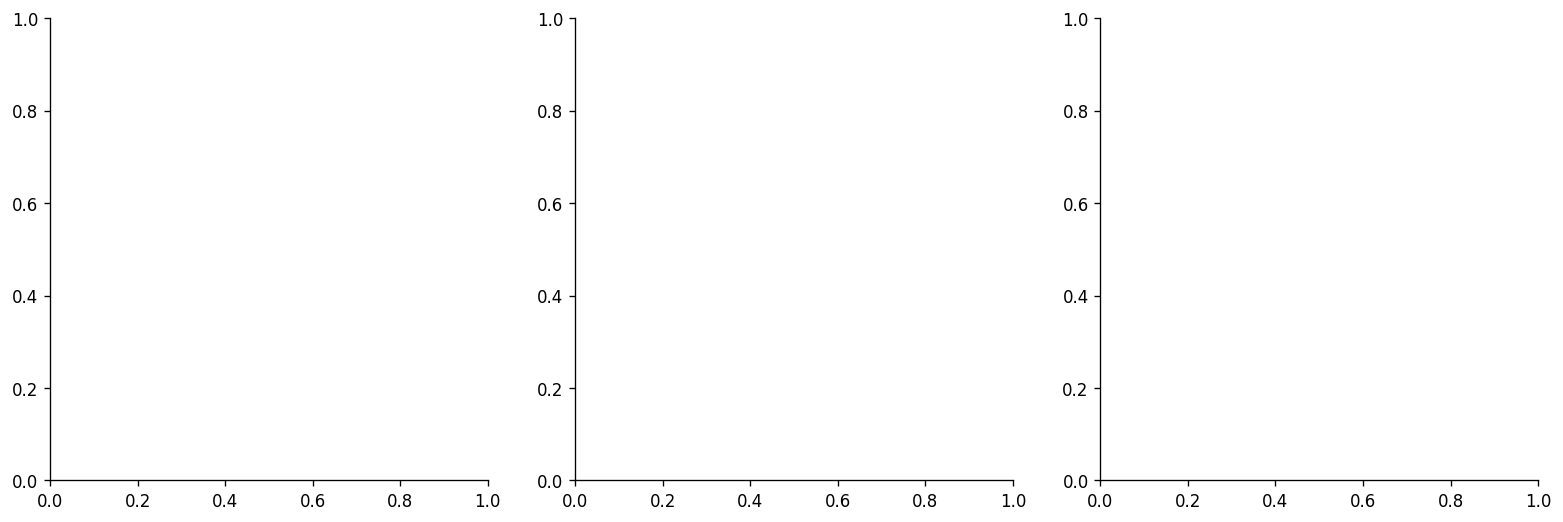

In [15]:

# ── Chart 6: Population Dynamics & Operational Capacity ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 6a — Annual mortality + pool stability
ax = axes[0]
ax.bar(years, ann_mort, color="#a50026", alpha=0.8, label="Mortality exits", width=0.8)
ax2t = ax.twinx()
ax2t.plot(years, pool_size, "k--", lw=1.5, label="Pool size")
ax2t.set_ylabel("Pool size", fontsize=9)
ax2t.set_ylim(cfg.SIMULATED_POPULATION * 0.8, cfg.SIMULATED_POPULATION * 1.2)
ax2t.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
ax.set_title("Annual Mortality & Pool Stability", fontsize=10, fontweight="bold")
ax.set_xlabel("Simulation Year"); ax.set_ylabel("Mortality exits")
ax.legend(loc="upper left", fontsize=8)
ax2t.legend(loc="upper right", fontsize=8)
ax.grid(axis="y", alpha=0.3)

# 6b — Annual screening throughput stacked
ax = axes[1]
ann_cerv_np = np.array(ann_cerv)
ann_lung_np = np.array(ann_lung)
ax.bar(years, ann_cerv_np, color="#4dac26", alpha=0.9, label="Cervical", width=0.8)
ax.bar(years, ann_lung_np, bottom=ann_cerv_np, color="#2c7bb6", alpha=0.9, label="Lung LDCT", width=0.8)
expected_cerv_yr = cfg.SIMULATED_POPULATION * 0.7 * (1/3)
ax.axhline(expected_cerv_yr, color="#1b7837", ls="--", lw=1.2, alpha=0.6,
           label=f"Expected cervical ~{expected_cerv_yr:.0f}/yr")
ax.set_title("Annual Screening Throughput", fontsize=10, fontweight="bold")
ax.set_xlabel("Simulation Year"); ax.set_ylabel("Screens completed")
ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

# 6c — Provider overflow
ax = axes[2]
overflow   = metrics_70yr.get("overflow", {})
providers  = ["pcp", "gynecologist", "specialist", "er"]
prov_lbls  = ["PCP", "Gynecologist", "Specialist", "ER"]
ov_counts  = [overflow.get(p, 0) for p in providers]
ov_colors  = ["#2c7bb6", "#4dac26", "#fdae61", "#d73027"]
bars = ax.bar(prov_lbls, ov_counts, color=ov_colors, edgecolor="white")
for bar, val in zip(bars, ov_counts):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(ov_counts + [1]) * 0.02,
            f"{val:,}", ha="center", fontsize=9)
ax.set_title("Provider Overflow\n(patients deferred, 70-yr total)", fontsize=10, fontweight="bold")
ax.set_ylabel("Overflow patient-days"); ax.grid(axis="y", alpha=0.3)

plt.suptitle("Population Dynamics & Operational Capacity", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("chart6_dynamics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 6 saved.")

# Close DB after all visualizations
sim_70yr.close_db()
print("Database connection closed.")


### Scheduling, Wait Times & Capacity

How long patients are waiting at each step, where providers are running over capacity, and whether annual screening volume is approaching the system's ceiling. These are the primary levers for operational planning — a gap between throughput and capacity means unmet demand; high P90 wait times flag bottlenecks where patients are most at risk of dropping out.

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# ── Chart 7: Scheduling, Wait Times & Capacity ───────────────────────────────
wt = metrics_70yr.get("wait_times", {})

resources_ordered = ['screening_seen', 'colposcopy', 'leep', 'lung_biopsy']
resource_labels   = {
    'screening_seen': 'Screening',
    'colposcopy':     'Colposcopy',
    'leep':           'LEEP',
    'lung_biopsy':    'Lung Biopsy',
}
res_colors = ['#1565C0', '#6A1B9A', '#E65100', '#C62828']

present = [
    (r, resource_labels[r], c)
    for r, c in zip(resources_ordered, res_colors)
    if r in wt and len(wt[r]) > 0
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Panel A: Wait time distributions per care step ────────────────────────────
ax = axes[0]
if present:
    box_data = [wt[r] for r, _, _ in present]
    box_lbls = [lbl for _, lbl, _ in present]
    bp = ax.boxplot(box_data, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='.', markersize=2, alpha=0.25))
    for patch, (_, _, col) in zip(bp['boxes'], present):
        patch.set_facecolor(col)
        patch.set_alpha(0.70)
    ax.set_xticklabels(box_lbls, fontsize=9)
    ax.set_ylabel('Days from patient creation to care step')
    ax.set_title('Wait Time Distribution by Care Step\n(70-year run, all patients)',
                 fontweight='bold', fontsize=10)
    for i, (res, _, _) in enumerate(present, 1):
        d = wt[res]
        ax.text(i, np.percentile(d, 97) * 1.03,
                f'P90={np.percentile(d, 90):.0f}d\nmed={np.median(d):.0f}d',
                ha='center', fontsize=7.5, color='#333')
else:
    ax.text(0.5, 0.5, 'No wait-time data recorded', ha='center', va='center',
            transform=ax.transAxes, color='gray', fontsize=11)

# ── Panel B: Provider overflow (capacity pressure) ────────────────────────────
ax = axes[1]
overflow  = metrics_70yr.get("overflow", {})
providers = ["pcp", "gynecologist", "specialist", "er"]
prov_lbls = ["PCP", "Gynecologist", "Specialist", "ER"]
ov_counts = [overflow.get(p, 0) for p in providers]
ov_colors = ['#2c7bb6', '#4dac26', '#fdae61', '#d73027']
total_days = cfg.SIM_YEARS * 365
bars = ax.bar(prov_lbls, ov_counts, color=ov_colors, edgecolor='white', alpha=0.85)
for bar, val in zip(bars, ov_counts):
    rate = val / total_days * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(ov_counts + [1]) * 0.02,
            f'{val:,}\n({rate:.1f}% of days)',
            ha='center', fontsize=8)
ax.set_ylabel('Patient overflow events (cumulative, 70 years)')
ax.set_title('Provider Overflow — Capacity Pressure\n(patients turned away on full-capacity days)',
             fontweight='bold', fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

# ── Panel C: Annual screening throughput vs. capacity ceiling ─────────────────
ax = axes[2]
chk = metrics_70yr.get("year_checkpoints", [])
if chk:
    years    = [c["year"] for c in chk]
    cum_cerv = [c["cum_cervical"] for c in chk]
    cum_lung = [c["cum_lung"]     for c in chk]
    ann_cerv = [cum_cerv[0]] + [cum_cerv[i] - cum_cerv[i-1] for i in range(1, len(cum_cerv))]
    ann_lung = [cum_lung[0]] + [cum_lung[i] - cum_lung[i-1] for i in range(1, len(cum_lung))]

    ax.stackplot(years, ann_cerv, ann_lung,
                 labels=['Cervical screenings', 'Lung LDCTs'],
                 colors=['#4472C4', '#70AD47'], alpha=0.82)

    # Total daily capacity across all providers × 365
    daily_total_cap = sum(cfg.PROVIDER_CAPACITY.values()) * 365
    ax.axhline(daily_total_cap, color='red', linewidth=2, linestyle='--',
               label=f'Capacity ceiling ({daily_total_cap:,}/yr)')

    ax.set_xlabel('Simulation Year')
    ax.set_ylabel('Screenings completed per year')
    ax.set_title('Annual Screening Volume vs. Capacity Ceiling\n(gap = unmet demand or headroom)',
                 fontweight='bold', fontsize=10)
    ax.legend(fontsize=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
else:
    ax.text(0.5, 0.5, 'No year checkpoint data', ha='center', va='center',
            transform=ax.transAxes, color='gray', fontsize=11)

plt.suptitle('Chart 7 — Scheduling, Wait Times & Capacity  (70-Year Simulation)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
if present:
    print(f"\n{'Step':<18} {'N patients':>12} {'Mean (d)':>10} {'Median':>8} {'P90':>8} {'Max':>8}")
    print("-" * 66)
    for res, lbl, _ in present:
        d = wt[res]
        print(f"{lbl:<18} {len(d):>12,} {np.mean(d):>10.1f} {np.median(d):>8.1f} "
              f"{np.percentile(d, 90):>8.1f} {max(d):>8}")
    total_ov = sum(ov_counts)
    print(f"\nTotal provider overflow events (70 yr): {total_ov:,}  "
          f"({total_ov / total_days:.2f} per day on average)")

NameError: name 'metrics_70yr' is not defined

---

## 1-Year Simulation

A single-year snapshot — useful for quickly checking how a parameter change affects screening throughput and outcomes before committing to a full 70-year run.

In [17]:

# ── Standalone run via SimulationRunner ───────────────────────────────────────
# This cell uses runner.py directly — no dependency on Sophia's SimPy notebook.
# SimulationRunner handles arrivals, queues, screening, and follow-up in one
# clean class. Switch use_stable_population=True for the 70-year cycling model.

import sys
sys.path.insert(0, '../src')

from runner import SimulationRunner
import config as cfg

print("Running 1-year simulation (SimulationRunner, standard mode)...")
sim = SimulationRunner(
    n_days     = 365,
    seed       = cfg.RANDOM_SEED,
    daily_rate = cfg.DAILY_PATIENTS,
    use_stable_population = False,   # standard mode: Poisson arrivals, no cycling
)
metrics = sim.run()

print(f"Done. Provider visits logged : {metrics['n_patients']:,}")
print(f"Eligible for any screening  : {metrics['n_eligible_any']:,}")
print(f"Cervical screened           : {metrics['n_screened']['cervical']:,}")
print(f"Lung screened               : {metrics['n_screened']['lung']:,}")
print()
sim.summary()


Running 1-year simulation (SimulationRunner, standard mode)...
Done. Provider visits logged : 71,712
Eligible for any screening  : 51,534
Cervical screened           : 49,838
Lung screened               : 2,407

NYP WOMEN'S HEALTH SCREENING SIMULATION — RESULTS

Patients simulated:                        71,712
Eligible for ≥1 screening:                 51,534
Unscreened (declined / no-show):           20,178  (28.1%)
  ↳ agreed to reschedule:                   9,968  (49.4% of unscreened)

Screenings completed by cancer type:
  cervical                 49,838
  lung                      2,407

Cervical result distribution  (n=49,838):
  ASC-H                             494  (1.0%)
  ASCUS                           1,205  (2.4%)
  HPV_NEGATIVE                   17,043  (34.2%)
  HPV_POSITIVE                    2,680  (5.4%)
  HSIL                              335  (0.7%)
  LSIL                            1,154  (2.3%)
  NORMAL                         26,927  (54.0%)
  Abnormal rate:  

### Screening Outcomes — 1-Year Snapshot

Where patients go after their provider visit. The primary metric is **how many eligible patients actually receive their USPSTF-recommended test** (cytology, hrHPV, or LDCT). Downstream results (abnormal rates, colposcopy, treatment) are shown for context but are secondary.


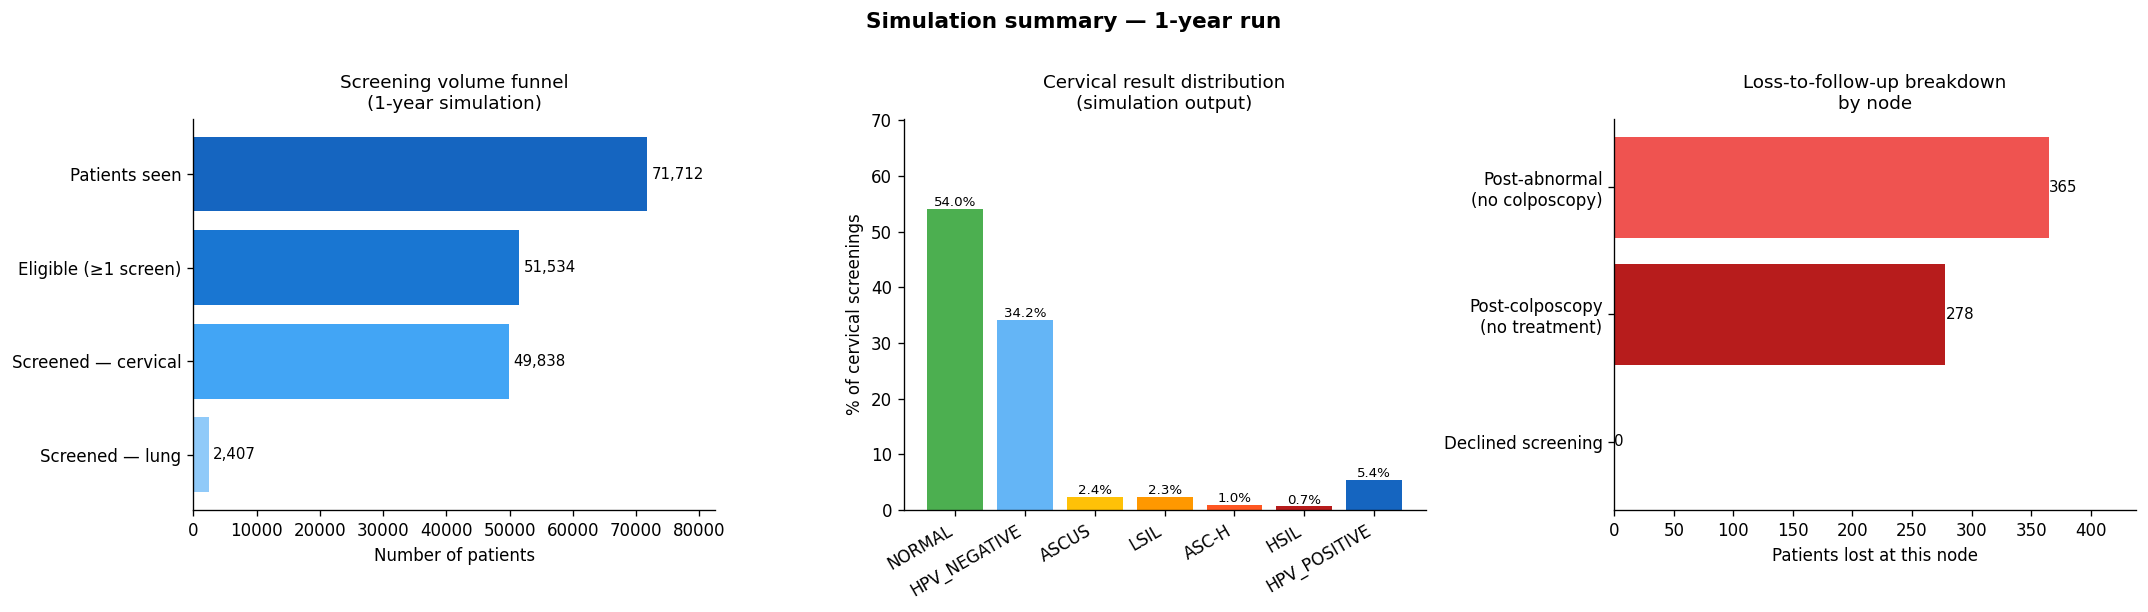

In [18]:
import matplotlib.pyplot as plt

# ── Panel 1: Screening Volume Funnel ──────────────────────────────────────────
# Each stage represents a gate the patient must pass through.
# The gap between consecutive stages is the drop-off at that point in the pathway.
stages  = ['Patients seen', 'Eligible (≥1 screen)', 'Screened — cervical', 'Screened — lung']
volumes = [
    metrics['n_patients'],
    metrics['n_eligible_any'],
    metrics['n_screened']['cervical'],
    metrics['n_screened']['lung'],
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
colors = ['#1565C0', '#1976D2', '#42A5F5', '#90CAF9']
# Reverse both lists so the first stage appears at the top of the horizontal chart
bars = ax.barh(stages[::-1], volumes[::-1], color=colors[::-1])
ax.set_xlabel('Number of patients')
ax.set_title('Screening volume funnel\n(1-year simulation)', fontsize=11)
# Annotate each bar with the patient count
for bar, vol in zip(bars, volumes[::-1]):
    ax.text(bar.get_width() + max(volumes)*0.01,
            bar.get_y() + bar.get_height()/2,
            f'{vol:,}', va='center', fontsize=9)
ax.set_xlim(0, max(volumes) * 1.15)

# ── Panel 2: Cervical Result Distribution ─────────────────────────────────────
# Only plot categories that actually appeared in the simulation results.
# Green = normal, yellow/orange/red spectrum = increasing severity of abnormality.
ax = axes[1]
if metrics['cervical_results']:
    cat_colors = {
        'NORMAL':        '#4CAF50',
        'HPV_NEGATIVE':  '#64B5F6',
        'ASCUS':         '#FFC107',
        'LSIL':          '#FF9800',
        'ASC-H':         '#FF5722',
        'HSIL':          '#B71C1C',
        'HPV_POSITIVE':  '#1565C0',
    }
    cats   = [c for c in cat_colors if metrics['cervical_results'].get(c, 0) > 0]
    counts = [metrics['cervical_results'][c] for c in cats]
    total  = sum(counts)
    pcts   = [c / total * 100 for c in counts]
    bar_colors = [cat_colors[c] for c in cats]

    bars2 = ax.bar(cats, pcts, color=bar_colors)
    ax.set_ylabel('% of cervical screenings')
    ax.set_title('Cervical result distribution\n(simulation output)', fontsize=11)
    ax.set_ylim(0, max(pcts) * 1.3)
    for bar, pct in zip(bars2, pcts):
        ax.text(bar.get_x() + bar.get_width()/2, pct + 0.5,
                f'{pct:.1f}%', ha='center', fontsize=8)
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
else:
    ax.text(0.5, 0.5, 'No cervical results\nin this run',
            ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Cervical result distribution')

# ── Panel 3: LTFU Breakdown by Node ──────────────────────────────────────────
# Each bar shows how many patients were lost at that specific decision point.
# Longer bars = bigger care gap = higher priority for intervention.
ax = axes[2]
nodes = ['Post-abnormal\n(no colposcopy)', 'Post-colposcopy\n(no treatment)', 'Declined screening']
ltfu  = [
    metrics['ltfu_post_abnormal'],
    metrics['ltfu_post_colposcopy'],
    metrics['ltfu_unscreened'],
]
ltfu_colors = ['#EF5350', '#B71C1C', '#BDBDBD']
bars3 = ax.barh(nodes[::-1], ltfu[::-1], color=ltfu_colors[::-1])
ax.set_xlabel('Patients lost at this node')
ax.set_title('Loss-to-follow-up breakdown\nby node', fontsize=11)
for bar, n in zip(bars3, ltfu[::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            str(n), va='center', fontsize=9)
ax.set_xlim(0, max(ltfu + [1]) * 1.2)

plt.suptitle('Simulation summary — 1-year run', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Lung Cancer Screening — USPSTF Uptake

Of all patients in the simulation who meet **USPSTF lung screening criteria** (age 50–80, ≥20 pack-years, currently smoking or quit ≤15 years ago), how many actually receive their annual LDCT scan?

The funnel below tracks the drop-off at each administrative step:
1. **USPSTF-eligible** — patient meets all three criteria
2. **Referral placed** — provider orders the LDCT
3. **Scan scheduled** — patient books an appointment
4. **Scan completed** — patient shows up

Each gap between steps is a lost opportunity — either the provider did not order the scan, or the patient did not follow through. These are the parameters to calibrate against NYP data.

> The Lung-RADS result distribution is shown for completeness, but the primary metric is the **completion rate**: what fraction of eligible patients actually received their scan.


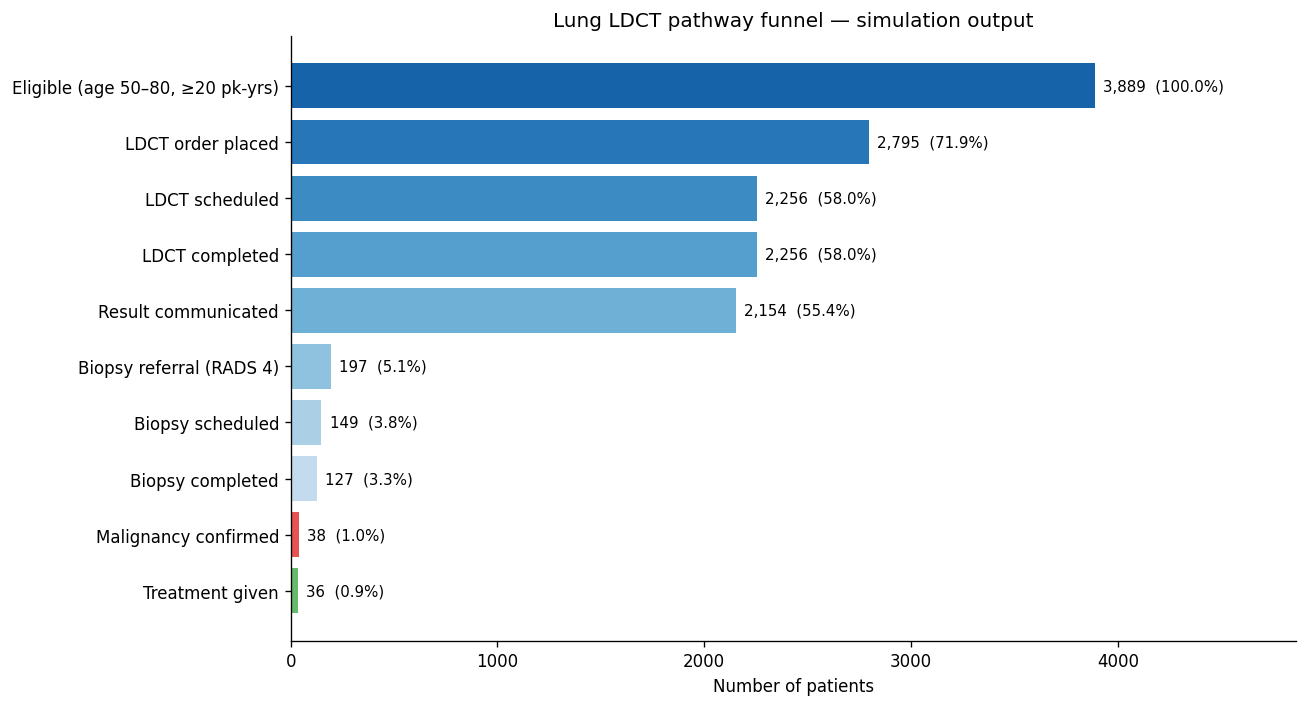

In [19]:
if metrics['lung_eligible'] > 0:
    # Each step in the lung pathway is tracked as a counter in metrics.
    # We read them in clinical order to build the funnel.
    steps = [
        ('Eligible (age 50–80, ≥20 pk-yrs)',  metrics['lung_eligible']),
        ('LDCT order placed',                  metrics['lung_referral_placed']),
        ('LDCT scheduled',                     metrics['lung_ldct_scheduled']),
        ('LDCT completed',                     metrics['lung_ldct_completed']),
        ('Result communicated',                metrics['lung_result_communicated']),
        ('Biopsy referral (RADS 4)',           metrics['lung_biopsy_referral']),
        ('Biopsy scheduled',                   metrics['lung_biopsy_scheduled']),
        ('Biopsy completed',                   metrics['lung_biopsy_completed']),
        ('Malignancy confirmed',               metrics['lung_malignancy_confirmed']),
        ('Treatment given',                    metrics['lung_treatment_given']),
    ]

    # Only show steps that had at least some patients reach them;
    # otherwise later biopsy/malignancy steps clutter the chart with zeros
    steps = [(label, count) for label, count in steps if count > 0]
    labels = [s[0] for s in steps]
    counts = [s[1] for s in steps]
    n_start = max(counts[0], 1)   # denominator for % calculation

    # Color gradient: blue for LDCT steps, red for biopsy/malignancy, green for treatment
    palette = plt.cm.Blues_r(range(50, 250, max(1, 200 // len(counts))))
    if len(counts) > 5:
        palette[-2] = (0.90, 0.33, 0.32, 1.0)   # malignancy confirmed — red
        palette[-1] = (0.40, 0.73, 0.42, 1.0)   # treatment given — green

    fig, ax = plt.subplots(figsize=(11, max(4, len(steps) * 0.6)))
    bars = ax.barh(labels[::-1], counts[::-1], color=palette[::-1])
    ax.set_xlabel('Number of patients')
    ax.set_title('Lung LDCT pathway funnel — simulation output', fontsize=12)

    # Annotate each bar: absolute count and % of eligible patients
    for bar, cnt in zip(bars, counts[::-1]):
        pct = cnt / n_start * 100
        ax.text(bar.get_width() + n_start * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{cnt:,}  ({pct:.1f}%)', va='center', fontsize=9)
    ax.set_xlim(0, n_start * 1.25)
    plt.tight_layout()
    plt.show()
else:
    print('No lung-eligible patients were seen in this simulation run.')

---

## Step-by-Step Breakdown

Technical walkthrough of the daily simulation engine. Shows how the arrivals layer, screening logic, queue processor, and event loop connect. Intended for development and debugging — the full model runs from `SimulationRunner` without any of the code below.

## Load Sophia's Arrival Functions

`%run` executes Sophia's notebook in its entirety and imports all of her functions and global variables into this notebook's namespace. This is equivalent to copy-pasting her code here, but means we always use her latest version without duplication.

After `%run`, we override only the patient-generation step (`generate_daily_arrivals`) to use our enriched `Patient` class — everything else (queue management, scheduling, ER routing) is hers unchanged.

**Namespace note**: `%run` will also load Sophia's `print_summary` function, which prints her arrivals summary. We import our own `print_summary` as `print_screening_summary` before this cell runs, so both can coexist.

In [20]:
%run "../archive/initial_model_NYP_flow_simulation (1).ipynb"

# Confirm Sophia's key functions are loaded
print('Sophia functions loaded:', [f for f in dir() if f in (
    'initialize_state', 'generate_daily_arrivals', 'process_provider_queue',
    'process_er_queue', 'release_scheduled_patients_for_today',
    'release_returning_er_patients', 'is_weekday', 'next_weekday',
)])

zsh:1: command not found: pip
ARRIVAL / ACCESS SUMMARY
Total patients created:               3000

Created by type:
  outpatient:                         2082
  drop_in:                            918

Created by destination:
  pcp:                                1088
  gynecologist:                       692
  specialist:                         629
  er:                                 591

Seen by destination:
  pcp:                                600
  gynecologist:                       450
  specialist:                         300
  er:                                 375

Drop-ins converted to outpatients:    694
Critical ER returned next day:        1035
Noncritical ER scheduled outpatient:  792

Outpatient showups:                   8040
Outpatient no-shows:                  0

DAY 0
--------------------------------------------------
--- DAY 0 START ---
Patient 1 arrives as outpatient to pcp
Patient 2 arrives as outpatient to pcp
Patient 3 arrives as drop-in to specialist
Pati

## Extended Patient Generation

Sophia's `generate_daily_arrivals` creates a plain `Patient` with only the fields her queue model needs (id, type, destination). We replace it with `generate_enriched_daily_arrivals` which calls `population.sample_patient` instead.

`sample_patient` draws the full clinical profile for each patient — age, race, insurance, HPV status, smoking history, BMI, prior CIN, etc. — from NYC-calibrated demographic distributions. These fields are what the screening eligibility checks and result-draw functions read when they evaluate the patient downstream.

This is the only change we make to the arrivals layer. Once a patient is created, Sophia's queue routing functions handle them the same way they would handle a plain `Patient` object.

In [21]:
def generate_enriched_daily_arrivals(day: int, state: dict, next_patient_id: int) -> int:
    """
    Generate DAILY_PATIENTS enriched patients for one weekday.

    Replaces Sophia's generate_daily_arrivals with population.sample_patient so
    each patient carries demographics and clinical flags from the population model.
    Queue routing logic (drop-in vs. outpatient, ER vs. PCP/GYN) mirrors Sophia's original.

    Returns the updated next_patient_id counter.
    """
    for _ in range(cfg.DAILY_PATIENTS):
        # Draw type and destination using config probability tables
        patient_type = random.choices(
            list(cfg.PATIENT_TYPE_PROBS.keys()),
            weights=list(cfg.PATIENT_TYPE_PROBS.values())
        )[0]
        destination = random.choices(
            list(cfg.DESTINATION_PROBS.keys()),
            weights=list(cfg.DESTINATION_PROBS.values())
        )[0]

        # sample_patient creates a Patient with age, race, clinical flags, etc.
        # from the population distribution — this is the enrichment over Sophia's version
        patient = sample_patient(next_patient_id, day, destination, patient_type)
        next_patient_id += 1

        # ER patients get a critical flag — critical patients return the next day
        # for follow-up instead of being routed to an outpatient queue
        if destination == 'er':
            patient.critical_status = random.random() < cfg.ER_CRITICAL_PROB

        # Append to global patient list and increment arrival counters
        state['all_patients'].append(patient)
        state['patients_created'] += 1
        state['created_by_type'][patient_type] += 1
        state['created_by_destination'][destination] += 1

        # Route into today's queue: outpatients go through scheduling,
        # ER drop-ins go directly to the ER queue
        if patient_type == 'outpatient':
            add_patient_to_today_queue(patient, state)
        elif destination == 'er':
            state['er_today'].append(patient)
        else:
            add_patient_to_today_queue(patient, state)

    return next_patient_id

print('generate_enriched_daily_arrivals defined')

generate_enriched_daily_arrivals defined


## Post-Provider Screening Step

This is the **integration point** between Sophia's layer and ours. Every time a patient is seen by a provider (PCP, GYN, or Specialist), we immediately run Steps 2–5:

1. **Eligibility** — `get_eligible_screenings` checks age, cervix status, and smoking history against USPSTF criteria for each active cancer type.
2. **Screening** — `run_screening_step` assigns the test modality and draws a stochastic result. For lung, it also runs the pre-LDCT referral + scheduling pathway.
3. **Follow-up** — `run_cervical_followup` or `run_lung_followup` routes the result through the clinical decision tree (colposcopy, biopsy, treatment).

Patients who are ineligible for all active cancers are counted and skipped. Patients who exit the system mid-encounter (e.g. lost to follow-up during lung pre-LDCT) are not processed for additional cancers.

In [22]:
def run_post_provider_screening(patient: Patient, day: int, metrics: dict) -> None:
    """
    Execute screening steps for one patient who has just been seen by a provider.
    Updates the patient object in place and writes results to metrics.

    Flow:
      1. Get the list of cancer types this patient is eligible for right now.
      2. If none → patient is not eligible for any active screening today; just count and return.
      3. For each eligible cancer → run_screening_step (lung pre-LDCT pathway runs inside).
      4. For each non-None result → route to cancer-specific follow-up function.
    """
    metrics['n_patients'] += 1

    # get_eligible_screenings filters by ACTIVE_CANCERS and applies all eligibility rules
    eligible = get_eligible_screenings(patient)

    if not eligible:
        # Patient doesn't meet criteria for any active cancer screening today
        # (wrong age, no cervix, not enough pack-years, etc.) — nothing to do
        metrics['n_unscreened'] += 1
        return

    metrics['n_eligible_any'] += 1

    for cancer in eligible:
        # If the patient exited mid-encounter (e.g. lost to follow-up in lung pre-LDCT),
        # stop processing further cancers for this visit
        if not patient.active:
            break

        # run_screening_step checks interval, assigns test, draws result, writes to patient.
        # Returns None if skipped (not yet due) or patient was lost before scan.
        # Passes metrics so lung funnel counters (referral, scheduled, completed) are populated.
        result = run_screening_step(patient, cancer, day, metrics=metrics)
        if result is None:
            continue  # not due yet, or lost before scan — no follow-up needed

        # Write the (cancer, result) pair to the metrics screening table
        record_screening(metrics, patient, cancer, result)

        # Route to the cancer-specific follow-up chain.
        # cervical: route_cervical_result → run_colposcopy → run_treatment
        # lung:     communicate → biopsy referral → biopsy → treatment
        # Other cancers are excluded by ACTIVE_CANCERS in get_eligible_screenings.
        if cancer == 'cervical':
            run_cervical_followup(patient, day, metrics)
        elif cancer == 'lung':
            run_lung_followup(patient, day, metrics)

        # If the follow-up chain marked the patient as exited, record that exit reason
        if patient.exit_reason:
            record_exit(metrics, patient.exit_reason)

print('run_post_provider_screening defined')

run_post_provider_screening defined


## Extended Provider Queue Processor

Sophia's `process_provider_queue` drains the daily queue for one provider type, marks patients as seen up to the day's capacity, and reschedules the overflow. We wrap it here to inject the screening step for every seen patient.

The ER is handled separately by Sophia's `process_er_queue` — we do not screen in the ER in the current model (no cancer screening is appropriate in an emergency setting).

In [23]:
def process_provider_queue_with_screening(
    day: int, queue: deque, capacity: int,
    provider_name: str, state: dict, metrics: dict
) -> None:
    """
    Sophia's provider queue logic plus a screening step for every seen patient.

    Patients up to `capacity` are marked seen; the rest are rescheduled.
    For each seen patient, run_post_provider_screening immediately triggers
    Steps 2–5 (eligibility → test → result → follow-up).
    """
    seen = 0

    while queue:
        patient = queue.popleft()

        if seen < capacity:
            # Patient is seen today — increment counter and log the visit
            seen += 1
            state['seen_by_destination'][provider_name] += 1
            log_day(state, day, f'Patient {patient.patient_id} seen by {provider_name}')

            # ── Steps 2–5: screening + follow-up ────────────────────────────
            # Runs immediately after the provider visit, same day
            run_post_provider_screening(patient, day, metrics)

        else:
            # Provider is at capacity — patient must wait and come back
            patient.wait_days += 1
            state['not_seen_by_destination'][provider_name] += 1

            # Drop-ins are converted to outpatient appointments for the next weekday;
            # already-scheduled outpatients are simply pushed to the next weekday slot
            if patient.patient_type == 'drop_in':
                patient.patient_type  = 'outpatient'
                patient.scheduled_day = next_weekday(day)
                state['future_schedule'][patient.scheduled_day].append(patient)
                state['converted_dropin_to_outpatient'] += 1
            else:
                patient.scheduled_day = next_weekday(day)
                state['future_schedule'][patient.scheduled_day].append(patient)

print('process_provider_queue_with_screening defined')

process_provider_queue_with_screening defined


## Main Daily Process (SimPy Generator)

This is the **SimPy event loop**. SimPy is a discrete-event simulation framework — rather than running a real clock, it steps through simulation time one day at a time. The `daily_process_with_screening` generator is registered with SimPy and called once per simulated day.

On each weekday, the generator:
1. Releases outpatients whose scheduled appointment falls on this day.
2. Brings back critical ER patients from the day before.
3. Generates new patient arrivals (enriched with clinical flags).
4. Drains the PCP, GYN, and Specialist queues — screening runs for each seen patient.
5. Drains the ER queue via Sophia's original processor.
6. Advances the clock by 1 day (`yield env.timeout(1)`).

Weekends are skipped entirely to match NYP's operating schedule.

In [24]:
def daily_process_with_screening(env, state: dict, metrics: dict):
    """
    SimPy generator: drives one simulated weekday at a time until SIM_DAYS.

    Each iteration:
      1. Skip weekends — yield a 1-day timeout and continue.
      2. Release scheduled outpatients whose appointment is today.
      3. Release returning ER patients (critical patients from yesterday).
      4. Generate new enriched arrivals (replaces Sophia's plain arrivals).
      5. Process PCP, GYN, and Specialist queues with integrated screening.
      6. Process ER queue using Sophia's original ER logic (no screening in ER).
      7. Advance SimPy clock by 1 day.
    """
    import simpy
    next_patient_id = 1

    while env.now < cfg.SIM_DAYS:
        day = int(env.now)

        # Skip weekends — Sophia's is_weekday() returns False for Sat/Sun
        if not is_weekday(day):
            yield env.timeout(1)
            continue

        # Pull today's scheduled outpatients out of future_schedule into their queues
        release_scheduled_patients_for_today(day, state)
        # Move critical ER patients from yesterday back to the ER queue
        release_returning_er_patients(day, state)

        # Generate DAILY_PATIENTS enriched arrivals and route them into queues
        next_patient_id = generate_enriched_daily_arrivals(day, state, next_patient_id)

        # Process each non-ER provider queue (steps 2–5 run inside for each seen patient)
        process_provider_queue_with_screening(
            day, state['pcp_today'],        cfg.PROVIDER_CAPACITY['pcp'],
            'pcp',          state, metrics
        )
        process_provider_queue_with_screening(
            day, state['gyn_today'],        cfg.PROVIDER_CAPACITY['gynecologist'],
            'gynecologist', state, metrics
        )
        process_provider_queue_with_screening(
            day, state['specialist_today'], cfg.PROVIDER_CAPACITY['specialist'],
            'specialist',   state, metrics
        )

        # ER uses Sophia's original processor — no cancer screening in the ER for now
        process_er_queue(day, state)

        # Advance clock by one day
        yield env.timeout(1)

print('daily_process_with_screening defined')

daily_process_with_screening defined


## Run the Simulation

`run_simulation` is the single entry point for a full model run. It:
- Seeds the random number generator so runs are reproducible.
- Creates a fresh SimPy environment (the discrete-event clock).
- Initialises both state dicts (Sophia's arrivals state and our screening metrics).
- Registers `daily_process_with_screening` with SimPy and advances to `sim_days`.

The quick test below runs **1 year (365 days)** with a fixed seed. For variance analysis, call `run_simulation` in a loop with different seeds and aggregate across replications.

In [25]:
import simpy

def run_simulation(
    sim_days: int = cfg.SIM_DAYS,
    seed:     int = cfg.RANDOM_SEED,
):
    """
    Run the full end-to-end simulation.

    Sets the random seed, creates a SimPy environment, initialises Sophia's
    arrivals state dict and our screening metrics dict, then advances the
    SimPy clock until sim_days.

    Returns
    -------
    state   : Sophia's arrivals state dict (patients_created, seen_by_destination, etc.)
    metrics : Steps 2–6 metrics dict (screened, abnormal rates, LTFU counts, etc.)
    """
    random.seed(seed)   # fix seed so results are reproducible across runs

    env     = simpy.Environment()   # SimPy clock starts at 0 (= day 0)
    state   = initialize_state()    # Sophia's arrivals state (queues, counters, schedule)
    metrics = initialize_metrics()  # our screening/follow-up metrics (from metrics.py)

    # Register the daily process as a SimPy generator — it yields timeout(1) each day
    env.process(daily_process_with_screening(env, state, metrics))
    env.run(until=sim_days)         # runs all days synchronously (no real concurrency)

    return state, metrics

print('run_simulation defined')

run_simulation defined


## Arrivals Summary (Sophia's Layer)

The cell below prints Sophia's arrivals summary from the same simulation run. This covers everything that happened *before* the screening step: how many patients were created, how many were seen by each provider type, how many were rescheduled due to capacity, and ER overflow statistics.

Use this alongside the screening summary above to understand both layers of the simulation — access bottlenecks upstream can reduce the number of patients who ever reach a screening opportunity.

In [26]:

# Sophia's arrivals summary is only available when her notebook was loaded via
# %run (cells above).  In standalone SimulationRunner mode, print a compact
# substitute using the metrics dict that is always present.

if 'state' in dir() and state is not None:
    # Sophia's layer is loaded — print her summary
    print_summary(state)
else:
    print("(Sophia's arrivals layer not loaded — standalone SimulationRunner mode)")
    print(f"  Total provider visits : {metrics['n_patients']:,}")
    print(f"  Eligible any cancer   : {metrics['n_eligible_any']:,}")
    print(f"  Cervical screened     : {metrics['n_screened']['cervical']:,}")
    print(f"  Lung screened         : {metrics['n_screened']['lung']:,}")
    print(f"  Colposcopies          : {metrics['n_colposcopy']:,}")
    print(f"  Treated               : {metrics['n_treated']:,}")
    print(f"  LTFU                  : {metrics['n_ltfu']:,}")


ARRIVAL / ACCESS SUMMARY
Total patients created:               3000

Created by type:
  outpatient:                         2082
  drop_in:                            918

Created by destination:
  pcp:                                1088
  gynecologist:                       692
  specialist:                         629
  er:                                 591

Seen by destination:
  pcp:                                600
  gynecologist:                       450
  specialist:                         300
  er:                                 375

Drop-ins converted to outpatients:    694
Critical ER returned next day:        1035
Noncritical ER scheduled outpatient:  792

Outpatient showups:                   8040
Outpatient no-shows:                  0


## Patient Event Log Trace

This section prints the full event-by-event history for a sample of individual patients.

Reading a patient trace is the best way to verify the clinical logic is flowing correctly end-to-end. Each line shows the simulated day and the event that occurred: screening, result, routing decision, colposcopy/biopsy, treatment, exit reason, etc.

If something is wrong in the model (e.g. a patient goes to colposcopy without an abnormal result, or a follow-up step fires for an ineligible patient), it will be visible here before it propagates into aggregate statistics.

In [27]:

# ── Patient event-log traces ──────────────────────────────────────────────────
# Sample a few patients, run them through screening manually, and print their
# event-by-event history.  Works standalone — no dependency on Sophia's state.

import random
random.seed(42)

from population import sample_patient
from screening import run_screening_step
from followup import run_cervical_followup, run_lung_followup
from metrics import initialize_metrics

traced = []
pid = 0
while len(traced) < 5 and pid < 200:
    dest  = random.choice(['pcp', 'gynecologist', 'specialist'])
    p     = sample_patient(pid, day_created=0, destination=dest, patient_type='outpatient')
    m     = initialize_metrics()

    for cancer in ['cervical', 'lung']:
        result = run_screening_step(p, cancer, 0, m)

        if cancer == 'cervical' and p.cervical_result not in (None, 'NORMAL', 'HPV_NEGATIVE'):
            run_cervical_followup(p, 30, m)
            if not p.active:               # re-activate so the loop can continue
                p.active      = True
                p.exit_reason = None
                p.exit_day    = None

        if cancer == 'lung' and p.lung_result is not None:
            run_lung_followup(p, 1, m)
            if not p.active:
                p.active      = True
                p.exit_reason = None
                p.exit_day    = None

    if p.event_log:
        traced.append(p)
    pid += 1

print(f"Traced {len(traced)} patients with events:\n")
for p in traced:
    p.print_history()
    print()


Traced 5 patients with events:


── Patient 0 | age=25 | destination=specialist ──
  Day     0: SCREEN cervical via cytology
  Day     0: RESULT cervical: NORMAL
  Day     0: SKIP lung — not eligible (age=25)


── Patient 1 | age=58 | destination=specialist ──
  Day     0: SCREEN cervical via cytology
  Day     0: RESULT cervical: LSIL
  Day    30: ROUTE LSIL → colposcopy
  Day    30: COLPOSCOPY → NORMAL
  Day    30: EXIT — untreated
  Day    30: LTFU — did not complete treatment after colposcopy
  Day     0: SKIP lung — not eligible (age=58)


── Patient 2 | age=50 | destination=gynecologist ──
  Day     0: SCREEN cervical via cytology
  Day     0: RESULT cervical: NORMAL
  Day     0: SKIP lung — not eligible (age=50)


── Patient 3 | age=73 | destination=gynecologist ──
  Day     0: SKIP cervical — not eligible (age=73)
  Day     0: SKIP lung — not eligible (age=73)


── Patient 4 | age=59 | destination=specialist ──
  Day     0: SCREEN cervical via cytology
  Day     0: RESULT cervi